# H2 fermionic-term noncommutation graph workflow

## Purpose

This notebook constructs the H2 fermionic Hamiltonian, groups raw OpenFermion monomials into Hermitian fermionic Hamiltonian terms, builds the fermionic noncommutation graph, colors the graph into commuting groups, and maps the same fermionic terms into Jordan-Wigner (JW) and Bravyi-Kitaev (BK) qubit operators.

## Main definitions

The molecular fermionic Hamiltonian is written as

```latex
H_f = \sum_i T_i.
```

Each graph vertex is a Hermitian fermionic Hamiltonian term:

```latex
T_i = c_i O_i + c_i^* O_i^\dagger
```

when the monomial is not already self-adjoint. If the monomial is already Hermitian, for example a number operator, then the term is kept once:

```latex
T_i = c_i O_i.
```

The graph is a noncommutation graph:

```latex
(T_i,T_j) \in E \quad \Longleftrightarrow \quad [T_i,T_j] \neq 0.
```

Therefore, a graph coloring of this noncommutation graph partitions the Hamiltonian into internally commuting blocks:

```latex
H_f = H_{red} + H_{blue} + \cdots,
\qquad
H_c = \sum_{T_i \in c} T_i.
```

Terms inside the same color commute and can be reordered freely within a first-order Trotter block. Different color blocks generally do not commute, so block ordering can affect Trotter error.

## Expected H2/STO-3G result

For the H2/STO-3G setup used here:

- Number of Hermitian fermionic vertices: 13
- Number of unordered vertex pairs: 78
- Number of noncommuting pairs / graph edges: 40
- Number of commuting pairs: 38
- The noncommutation graph is bipartite, so two colors are sufficient for this example.

These numbers can change if the bond length, basis, active space, or term-grouping convention changes.

## Code organization

### Cell 1
Builds the H2 fermionic Hamiltonian and stores Hermitian fermionic terms in `hermitian_terms`.

### Cell 2
Builds the noncommutation graph `G`, where each vertex is a fermionic term `T_i` and each edge is a nonzero fermionic commutator.

### Cell 3
Colors the graph into commuting groups, forms color-block Hamiltonians, maps each fermionic term and block into JW and BK, and verifies that terms inside each color group commute after JW/BK mapping.

## Important interpretation

JW and BK should be applied to the same fermionic source terms:

```latex
T_i \mapsto JW(T_i),
\qquad
T_i \mapsto BK(T_i).
```

The Pauli strings produced by JW and BK can differ, but they represent the same original fermionic operator. If two fermionic terms commute, their full mapped JW operators commute, and their full mapped BK operators also commute. A single fermionic term may map to a sum of Pauli strings, so the statement is about the full mapped operator, not necessarily every individual Pauli string in the expansion.

In [2]:
# Cell 1: Build H2 fermionic Hamiltonian and Hermitian fermionic terms

import pandas as pd

from openfermion.chem import MolecularData
from openfermion.ops import FermionOperator
from openfermion.transforms import get_fermion_operator, normal_ordered
from openfermion.utils import hermitian_conjugated
from openfermionpyscf import run_pyscf

pd.set_option("display.max_colwidth", None)


def format_fermion_term(term):
    if term == ():
        return "I"

    pieces = []
    for orbital, action in term:
        if action == 1:
            pieces.append(f"a_{orbital}^dagger")
        else:
            pieces.append(f"a_{orbital}")
    return " ".join(pieces)


def sort_fermion_key(term):
    return (len(term), term)


def coeff_to_str(c, digits=8):
    c = complex(c)
    if abs(c.imag) < 1e-12:
        return f"{c.real:+.{digits}f}"
    return f"{c.real:+.{digits}f}{c.imag:+.{digits}f}j"


def operator_to_string(op, digits=8):
    pieces = []

    for term, coeff in sorted(op.terms.items(), key=lambda item: sort_fermion_key(item[0])):
        pieces.append(f"{coeff_to_str(coeff, digits)} {format_fermion_term(term)}")

    if len(pieces) == 0:
        return "0"

    return " + ".join(pieces)


def dagger_term_key(term):
    """
    Return the OpenFermion key for O^dagger, where O is one monomial.
    """
    O = FermionOperator(term, 1.0)
    O_dag = normal_ordered(hermitian_conjugated(O))
    O_dag.compress(abs_tol=1e-12)

    if len(O_dag.terms) != 1:
        raise ValueError(f"Expected one dagger term, got: {O_dag}")

    return next(iter(O_dag.terms.keys()))


def make_hermitian_fermionic_terms(fermion_hamiltonian, tol=1e-12):
    """
    Group raw monomials into Hermitian fermionic Hamiltonian terms.

    If O is self-adjoint, keep c O.
    If O is not self-adjoint, group c O + c* O^dagger.
    """
    used = set()
    hermitian_terms = []

    for term, coeff in fermion_hamiltonian.terms.items():
        if term in used:
            continue

        dag = dagger_term_key(term)

        if dag == term:
            T = FermionOperator(term, coeff)
            used.add(term)
        else:
            dag_coeff = fermion_hamiltonian.terms.get(dag, 0.0)

            T = FermionOperator(term, coeff)
            T += FermionOperator(dag, dag_coeff)

            used.add(term)
            used.add(dag)

        T = normal_ordered(T)
        T.compress(abs_tol=tol)
        hermitian_terms.append(T)

    return hermitian_terms


def build_h2_fermionic_hamiltonian(
    bond_length=0.7414,
    basis="sto-3g",
    multiplicity=1,
    charge=0,
):
    geometry = [
        ("H", (0.0, 0.0, 0.0)),
        ("H", (0.0, 0.0, bond_length)),
    ]

    molecule = MolecularData(
        geometry=geometry,
        basis=basis,
        multiplicity=multiplicity,
        charge=charge,
        description=f"H2_{bond_length}",
    )

    molecule = run_pyscf(
        molecule,
        run_scf=True,
        run_fci=True,
    )

    molecular_hamiltonian = molecule.get_molecular_hamiltonian()
    fermion_hamiltonian = get_fermion_operator(molecular_hamiltonian)

    fermion_hamiltonian = normal_ordered(fermion_hamiltonian)
    fermion_hamiltonian.compress(abs_tol=1e-12)

    return molecule, fermion_hamiltonian


# ------------------------------------------------------------
# Build H2 fermionic Hamiltonian
# ------------------------------------------------------------

molecule, Hf = build_h2_fermionic_hamiltonian(
    bond_length=0.7414,
    basis="sto-3g",
)

hermitian_terms = make_hermitian_fermionic_terms(Hf)

print("Molecule: H2")
print("Basis: STO-3G")
print("Number of electrons:", molecule.n_electrons)
print("Number of spatial orbitals:", molecule.n_orbitals)
print("Number of spin orbitals / fermionic modes:", molecule.n_qubits)
print("Number of raw OpenFermion monomial terms:", len(Hf.terms))
print("Number of Hermitian fermionic terms:", len(hermitian_terms))

print("\n=== Full fermionic Hamiltonian H_f ===")
print(Hf)


# ------------------------------------------------------------
# Tables
# ------------------------------------------------------------

raw_rows = []

for idx, (term, coeff) in enumerate(
    sorted(Hf.terms.items(), key=lambda item: sort_fermion_key(item[0]))
):
    raw_rows.append(
        {
            "raw_index": idx,
            "coefficient": coeff_to_str(coeff),
            "monomial": format_fermion_term(term),
            "OpenFermion_key": term,
        }
    )

raw_df = pd.DataFrame(raw_rows)

print("\n=== Raw fermionic monomials c_alpha O_alpha ===")
display(raw_df)


hermitian_rows = []

for i, T in enumerate(hermitian_terms):
    hermitian_rows.append(
        {
            "vertex": f"T_{i}",
            "number_of_monomials": len(T.terms),
            "fermionic_term": operator_to_string(T),
        }
    )

hermitian_df = pd.DataFrame(hermitian_rows)

print("\n=== Hermitian fermionic terms T_i ===")
display(hermitian_df)

Molecule: H2
Basis: STO-3G
Number of electrons: 2
Number of spatial orbitals: 2
Number of spin orbitals / fermionic modes: 4
Number of raw OpenFermion monomial terms: 15
Number of Hermitian fermionic terms: 13

=== Full fermionic Hamiltonian H_f ===
0.7137539936876182 [] +
-1.2524635735648986 [0^ 0] +
-0.6744887663568376 [1^ 0^ 1 0] +
-0.18128880821149587 [1^ 0^ 3 2] +
-1.2524635735648986 [1^ 1] +
-0.48217928821207157 [2^ 0^ 2 0] +
-0.6634680964235674 [2^ 1^ 2 1] +
0.18128880821149587 [2^ 1^ 3 0] +
-0.47594871522096466 [2^ 2] +
0.18128880821149587 [3^ 0^ 2 1] +
-0.6634680964235674 [3^ 0^ 3 0] +
-0.48217928821207157 [3^ 1^ 3 1] +
-0.18128880821149587 [3^ 2^ 1 0] +
-0.6973937674230251 [3^ 2^ 3 2] +
-0.47594871522096466 [3^ 3]

=== Raw fermionic monomials c_alpha O_alpha ===


,raw_index,coefficient,monomial,OpenFermion_key
0,0,+0.71375399,I,()
1,1,-1.25246357,a_0^dagger a_0,"((0, 1), (0, 0))"
2,2,-1.25246357,a_1^dagger a_1,"((1, 1), (1, 0))"
3,3,-0.47594872,a_2^dagger a_2,"((2, 1), (2, 0))"
4,4,-0.47594872,a_3^dagger a_3,"((3, 1), (3, 0))"
5,5,-0.67448877,a_1^dagger a_0^dagger a_1 a_0,"((1, 1), (0, 1), (1, 0), (0, 0))"
6,6,-0.18128881,a_1^dagger a_0^dagger a_3 a_2,"((1, 1), (0, 1), (3, 0), (2, 0))"
7,7,-0.48217929,a_2^dagger a_0^dagger a_2 a_0,"((2, 1), (0, 1), (2, 0), (0, 0))"
8,8,-0.66346810,a_2^dagger a_1^dagger a_2 a_1,"((2, 1), (1, 1), (2, 0), (1, 0))"
9,9,+0.18128881,a_2^dagger a_1^dagger a_3 a_0,"((2, 1), (1, 1), (3, 0), (0, 0))"



=== Hermitian fermionic terms T_i ===


,vertex,number_of_monomials,fermionic_term
0,T_0,1,+0.71375399 I
1,T_1,1,-1.25246357 a_0^dagger a_0
2,T_2,1,-1.25246357 a_1^dagger a_1
3,T_3,1,-0.47594872 a_2^dagger a_2
4,T_4,1,-0.47594872 a_3^dagger a_3
5,T_5,1,-0.67448877 a_1^dagger a_0^dagger a_1 a_0
6,T_6,2,-0.18128881 a_1^dagger a_0^dagger a_3 a_2 + -0.18128881 a_3^dagger a_2^dagger a_1 a_0
7,T_7,1,-0.48217929 a_2^dagger a_0^dagger a_2 a_0
8,T_8,2,+0.18128881 a_2^dagger a_1^dagger a_3 a_0 + +0.18128881 a_3^dagger a_0^dagger a_2 a_1
9,T_9,1,-0.66346810 a_3^dagger a_0^dagger a_3 a_0


=== Fermionic noncommutation graph alpha summary ===


,total_pairs,pairs_skipped_by_index_rules,skip_identity,skip_disjoint_even_support,skip_diagonal_diagonal,pairs_sent_to_exact_symbolic,noncommuting_edges,exact_symbolic_found_commuting,vertices,edges,commuting_pairs,elapsed_seconds
0,78,57,12,21,24,21,12,9,13,12,66,0.00107


Number of vertices / fermionic terms: 13
Number of noncommuting pairs / edges: 12
Is graph bipartite? True

=== Alpha vertices: fermionic terms ===


,vertex,degree,commutes_with_all,number_of_monomials,modes,is_diagonal,fermionic_term
0,T_0,0,True,1,[],True,+0.71375399 I
1,T_1,2,False,1,[0],True,-1.25246357 a_0^dagger a_0
2,T_2,2,False,1,[1],True,-1.25246357 a_1^dagger a_1
3,T_3,2,False,1,[2],True,-0.47594872 a_2^dagger a_2
4,T_4,2,False,1,[3],True,-0.47594872 a_3^dagger a_3
5,T_5,1,False,1,"[0, 1]",True,-0.67448877 a_1^dagger a_0^dagger a_1 a_0
6,T_6,6,False,2,"[0, 1, 2, 3]",False,-0.18128881 a_1^dagger a_0^dagger a_3 a_2 + -0.18128881 a_3^dagger a_2^dagger a_1 a_0
7,T_7,0,True,1,"[0, 2]",True,-0.48217929 a_2^dagger a_0^dagger a_2 a_0
8,T_8,6,False,2,"[0, 1, 2, 3]",False,+0.18128881 a_2^dagger a_1^dagger a_3 a_0 + +0.18128881 a_3^dagger a_0^dagger a_2 a_1
9,T_9,1,False,1,"[0, 3]",True,-0.66346810 a_3^dagger a_0^dagger a_3 a_0



=== Alpha edges: noncommuting pairs ===


,source,target,meaning,method,commutator
0,T_1,T_6,"[T_1, T_6] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
1,T_1,T_8,"[T_1, T_8] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
2,T_2,T_6,"[T_2, T_6] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
3,T_2,T_8,"[T_2, T_8] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
4,T_3,T_6,"[T_3, T_6] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
5,T_3,T_8,"[T_3, T_8] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
6,T_4,T_6,"[T_4, T_6] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
7,T_4,T_8,"[T_4, T_8] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
8,T_5,T_6,"[T_5, T_6] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
9,T_6,T_12,"[T_6, T_12] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)


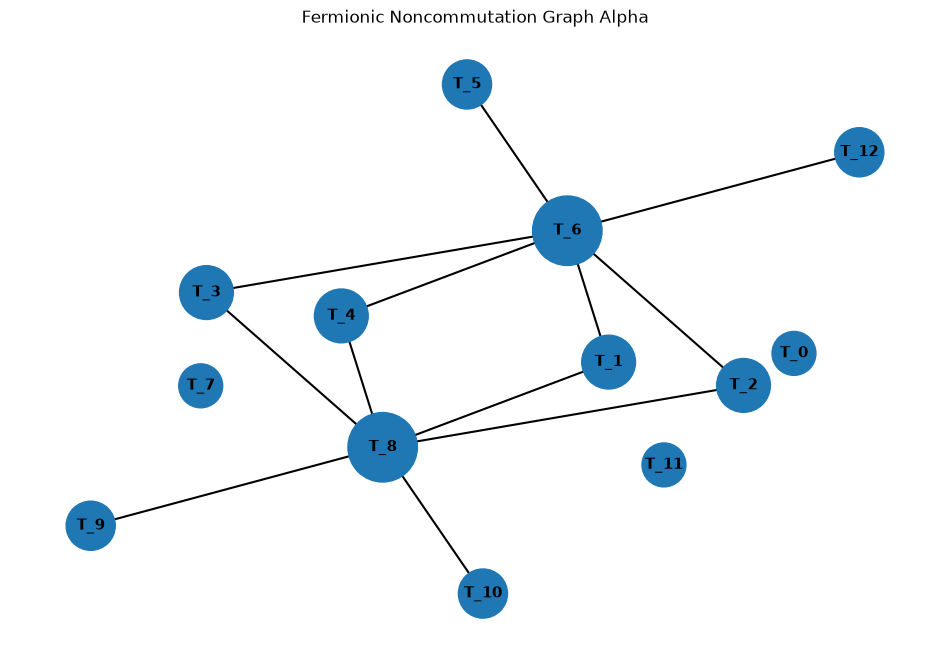

In [3]:
# Cell 2 alpha: Faster H2 / molecular fermionic noncommutation graph
#
# Main idea:
#   1. Use cheap fermionic index rules first.
#   2. Only if rules cannot decide, use exact OpenFermion symbolic commutator.
#   3. Never build sparse/dense matrices.
#
# This cell assumes Cell 1 already defined:
#   hermitian_terms
#   operator_to_string

import time
from collections import Counter

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from openfermion.utils import commutator
from openfermion.transforms import normal_ordered

pd.set_option("display.max_colwidth", None)


# ------------------------------------------------------------
# Fermionic key utilities
# ------------------------------------------------------------

def key_modes(key):
    """
    Modes appearing in one OpenFermion monomial key.

    Example:
        ((3, 1), (0, 1), (3, 0), (0, 0)) -> {0, 3}
    """
    return frozenset(mode for mode, action in key)


def key_creations(key):
    """
    Creation modes in one monomial.
    """
    return frozenset(mode for mode, action in key if action == 1)


def key_annihilations(key):
    """
    Annihilation modes in one monomial.
    """
    return frozenset(mode for mode, action in key if action == 0)


def key_net_delta(key):
    """
    Net occupation change caused by a monomial.

    creation contributes +1
    annihilation contributes -1

    For example:
        a_2^dagger a_1^dagger a_3 a_0
    has delta:
        +1 on modes 2 and 1
        -1 on modes 3 and 0
    """
    delta = Counter()

    for mode, action in key:
        if action == 1:
            delta[mode] += 1
        else:
            delta[mode] -= 1

    return delta


def is_diagonal_key(key):
    """
    True if a monomial preserves occupation mode-by-mode.

    Examples:
        a_p^dagger a_p is diagonal.
        a_p^dagger a_q^dagger a_q a_p is diagonal.
        a_p^dagger a_q is not diagonal when p != q.
    """
    delta = key_net_delta(key)
    return all(value == 0 for value in delta.values())


def is_even_key(key):
    """
    Electronic Hamiltonian terms normally have even fermionic parity:
    length 0, 2, or 4.
    """
    return len(key) % 2 == 0


# ------------------------------------------------------------
# Safe monomial-level commutation rules
# ------------------------------------------------------------

def diagonal_key_commutes_with_key(diagonal_key, other_key):
    """
    Safe rule:

    A diagonal occupation operator depending on modes S commutes with another
    monomial if the other monomial has zero net occupation change on every
    mode in S.
    """
    support = key_modes(diagonal_key)
    delta = key_net_delta(other_key)

    return all(delta.get(mode, 0) == 0 for mode in support)


def no_cross_contractions_even_commute(key_a, key_b):
    """
    Safe rule for normal-ordered even fermionic monomials.

    If there are no possible cross contractions:
        annihilations(A) intersect creations(B) = empty
        annihilations(B) intersect creations(A) = empty

    then even monomials commute.

    This catches many cases beyond completely disjoint support.
    """
    if not is_even_key(key_a) or not is_even_key(key_b):
        return False

    a_ann = key_annihilations(key_a)
    a_cre = key_creations(key_a)

    b_ann = key_annihilations(key_b)
    b_cre = key_creations(key_b)

    return a_ann.isdisjoint(b_cre) and b_ann.isdisjoint(a_cre)


def monomial_pair_definitely_commutes(key_a, key_b):
    """
    Return (True, reason) only when we are sure two monomials commute.
    Return (False, None) if the rule cannot decide.

    Important:
        False here does NOT mean noncommuting.
        It only means "unknown; use exact symbolic fallback."
    """
    # Identity commutes with everything.
    if key_a == () or key_b == ():
        return True, "identity"

    # Any monomial commutes with itself.
    if key_a == key_b:
        return True, "same_monomial"

    # Diagonal occupation-like monomials commute with each other.
    if is_diagonal_key(key_a) and is_diagonal_key(key_b):
        return True, "diagonal_diagonal"

    # Diagonal with excitation-like term, if excitation preserves diagonal support.
    if is_diagonal_key(key_a) and diagonal_key_commutes_with_key(key_a, key_b):
        return True, "diagonal_support_preserved"

    if is_diagonal_key(key_b) and diagonal_key_commutes_with_key(key_b, key_a):
        return True, "diagonal_support_preserved"

    # Even monomials with no cross contractions commute.
    if no_cross_contractions_even_commute(key_a, key_b):
        return True, "no_cross_contractions_even"

    return False, None


# ------------------------------------------------------------
# Operator-level metadata and precheck
# ------------------------------------------------------------

def operator_metadata(op):
    """
    Precompute simple structural data for one FermionOperator.
    """
    keys = list(op.terms.keys())

    modes = set()
    for key in keys:
        modes.update(key_modes(key))

    return {
        "is_zero": len(keys) == 0,
        "only_identity": len(keys) == 1 and keys[0] == (),
        "modes": frozenset(modes),
        "is_even": all(is_even_key(key) for key in keys),
        "is_diagonal": all(is_diagonal_key(key) for key in keys),
        "number_of_monomials": len(keys),
    }


def operator_pair_definitely_commutes(A, B, meta_A, meta_B):
    """
    Return (True, reason) only for guaranteed-commuting pairs.
    Return (False, None) when unresolved.
    """
    if meta_A["is_zero"] or meta_B["is_zero"]:
        return True, "zero"

    if meta_A["only_identity"] or meta_B["only_identity"]:
        return True, "identity"

    # Very cheap global rule:
    # disjoint even fermionic operators commute.
    if (
        meta_A["is_even"]
        and meta_B["is_even"]
        and meta_A["modes"].isdisjoint(meta_B["modes"])
    ):
        return True, "disjoint_even_support"

    # Diagonal occupation-like operators commute with each other.
    if meta_A["is_diagonal"] and meta_B["is_diagonal"]:
        return True, "diagonal_diagonal"

    # More detailed but still cheap:
    # if every monomial pair has a safe commuting reason, the sums commute.
    reasons = Counter()

    for key_a in A.terms:
        for key_b in B.terms:
            ok, reason = monomial_pair_definitely_commutes(key_a, key_b)

            if not ok:
                return False, None

            reasons[reason] += 1

    if len(reasons) > 0:
        main_reason = reasons.most_common(1)[0][0]
        return True, f"all_monomial_pairs_{main_reason}"

    return False, None


# ------------------------------------------------------------
# Exact symbolic fallback
# ------------------------------------------------------------

def exact_symbolic_fermionic_commutator(A, B, tol=1e-12):
    """
    Exact symbolic commutator in fermionic algebra.

    This does not build a 2^n matrix.
    """
    C = normal_ordered(commutator(A, B))
    C.compress(abs_tol=tol)
    return C


# ------------------------------------------------------------
# Alpha graph builder
# ------------------------------------------------------------

def build_fermionic_noncommutation_graph_alpha(
    hermitian_terms,
    tol=1e-12,
    store_commutators=False,
):
    """
    Build noncommutation graph using:
        fast safe index rules first,
        exact symbolic OpenFermion fallback only when needed.

    Parameters
    ----------
    hermitian_terms:
        list of FermionOperator terms T_i from Cell 1.

    tol:
        numerical compression tolerance.

    store_commutators:
        False is recommended for large molecules.
        True is useful for H2 debugging, but can be memory-heavy.

    Returns
    -------
    G:
        networkx.Graph

    stats_df:
        pandas.DataFrame with timing and skip counts
    """
    t_start = time.perf_counter()

    G = nx.Graph()
    stats = Counter()

    metadata = [operator_metadata(T) for T in hermitian_terms]

    # Add vertices.
    for i, T in enumerate(hermitian_terms):
        G.add_node(
            i,
            label=f"T_{i}",
            operator=T,
            operator_string=operator_to_string(T),
            number_of_monomials=len(T.terms),
            modes=sorted(metadata[i]["modes"]),
            is_diagonal=metadata[i]["is_diagonal"],
            is_even=metadata[i]["is_even"],
        )

    n = len(hermitian_terms)

    # Pairwise graph construction.
    for i in range(n):
        A = hermitian_terms[i]
        meta_A = metadata[i]

        for j in range(i + 1, n):
            B = hermitian_terms[j]
            meta_B = metadata[j]

            stats["total_pairs"] += 1

            # 1. Fast guaranteed-commuting rules.
            definitely_commutes, reason = operator_pair_definitely_commutes(
                A, B, meta_A, meta_B
            )

            if definitely_commutes:
                stats["pairs_skipped_by_index_rules"] += 1
                stats[f"skip_{reason}"] += 1
                continue

            # 2. Exact symbolic fallback.
            stats["pairs_sent_to_exact_symbolic"] += 1

            Cij = exact_symbolic_fermionic_commutator(A, B, tol=tol)

            if len(Cij.terms) != 0:
                stats["noncommuting_edges"] += 1

                edge_data = {
                    "method": "exact_symbolic_fallback",
                    "meaning": f"[T_{i}, T_{j}] != 0",
                }

                if store_commutators:
                    edge_data["commutator"] = Cij
                    edge_data["commutator_string"] = operator_to_string(Cij)
                else:
                    edge_data["commutator_string"] = (
                        "(not stored; rerun with store_commutators=True)"
                    )

                G.add_edge(i, j, **edge_data)

            else:
                stats["exact_symbolic_found_commuting"] += 1

    elapsed = time.perf_counter() - t_start

    stats["vertices"] = n
    stats["edges"] = G.number_of_edges()
    stats["commuting_pairs"] = stats["total_pairs"] - G.number_of_edges()
    stats["elapsed_seconds"] = elapsed

    stats_df = pd.DataFrame([dict(stats)])

    return G, stats_df


# ------------------------------------------------------------
# Run alpha graph builder
# ------------------------------------------------------------

# For H2 debugging, you can set store_commutators=True.
# For larger molecules, keep this False.
G_alpha, stats_df = build_fermionic_noncommutation_graph_alpha(
    hermitian_terms,
    tol=1e-12,
    store_commutators=False,
)

print("=== Fermionic noncommutation graph alpha summary ===")
display(stats_df)

print("Number of vertices / fermionic terms:", G_alpha.number_of_nodes())
print("Number of noncommuting pairs / edges:", G_alpha.number_of_edges())
print("Is graph bipartite?", nx.is_bipartite(G_alpha))


# ------------------------------------------------------------
# Vertex table
# ------------------------------------------------------------

vertex_rows = []

for i, data in G_alpha.nodes(data=True):
    vertex_rows.append(
        {
            "vertex": f"T_{i}",
            "degree": G_alpha.degree[i],
            "commutes_with_all": G_alpha.degree[i] == 0,
            "number_of_monomials": data["number_of_monomials"],
            "modes": data["modes"],
            "is_diagonal": data["is_diagonal"],
            "fermionic_term": data["operator_string"],
        }
    )

vertex_df_alpha = pd.DataFrame(vertex_rows)

print("\n=== Alpha vertices: fermionic terms ===")
display(vertex_df_alpha)


# ------------------------------------------------------------
# Edge table
# ------------------------------------------------------------

edge_rows = []

for i, j, data in G_alpha.edges(data=True):
    edge_rows.append(
        {
            "source": f"T_{i}",
            "target": f"T_{j}",
            "meaning": data["meaning"],
            "method": data["method"],
            "commutator": data["commutator_string"],
        }
    )

edge_df_alpha = pd.DataFrame(edge_rows)

print("\n=== Alpha edges: noncommuting pairs ===")
display(edge_df_alpha)


# ------------------------------------------------------------
# Draw graph
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

pos = nx.kamada_kawai_layout(G_alpha)

node_labels = {
    i: f"T_{i}"
    for i in G_alpha.nodes()
}

node_sizes = [
    1000 + 250 * G_alpha.degree[i]
    for i in G_alpha.nodes()
]

nx.draw_networkx_nodes(G_alpha, pos, node_size=node_sizes)
nx.draw_networkx_edges(G_alpha, pos, width=1.5)
nx.draw_networkx_labels(
    G_alpha,
    pos,
    labels=node_labels,
    font_size=11,
    font_weight="bold",
)

plt.title("Fermionic Noncommutation Graph Alpha")
plt.axis("off")
plt.show()

=== Fermionic noncommutation graph summary ===
Number of vertices / fermionic terms: 13
Number of total unordered pairs: 78
Number of noncommuting pairs / edges: 12
Number of commuting pairs: 66
Is graph bipartite? True

=== Vertices: fermionic terms ===


,vertex,degree,commutes_with_all,fermionic_term
0,T_0,0,True,+0.71375399 I
1,T_1,2,False,-1.25246357 a_0^dagger a_0
2,T_2,2,False,-1.25246357 a_1^dagger a_1
3,T_3,2,False,-0.47594872 a_2^dagger a_2
4,T_4,2,False,-0.47594872 a_3^dagger a_3
5,T_5,1,False,-0.67448877 a_1^dagger a_0^dagger a_1 a_0
6,T_6,6,False,-0.18128881 a_1^dagger a_0^dagger a_3 a_2 + -0.18128881 a_3^dagger a_2^dagger a_1 a_0
7,T_7,0,True,-0.48217929 a_2^dagger a_0^dagger a_2 a_0
8,T_8,6,False,+0.18128881 a_2^dagger a_1^dagger a_3 a_0 + +0.18128881 a_3^dagger a_0^dagger a_2 a_1
9,T_9,1,False,-0.66346810 a_3^dagger a_0^dagger a_3 a_0



=== Edges: noncommuting pairs ===


,source,target,meaning,commutator
0,T_1,T_6,"[T_1, T_6] != 0",+0.22705763 a_1^dagger a_0^dagger a_3 a_2 + -0.22705763 a_3^dagger a_2^dagger a_1 a_0
1,T_1,T_8,"[T_1, T_8] != 0",+0.22705763 a_2^dagger a_1^dagger a_3 a_0 + -0.22705763 a_3^dagger a_0^dagger a_2 a_1
2,T_2,T_6,"[T_2, T_6] != 0",+0.22705763 a_1^dagger a_0^dagger a_3 a_2 + -0.22705763 a_3^dagger a_2^dagger a_1 a_0
3,T_2,T_8,"[T_2, T_8] != 0",-0.22705763 a_2^dagger a_1^dagger a_3 a_0 + +0.22705763 a_3^dagger a_0^dagger a_2 a_1
4,T_3,T_6,"[T_3, T_6] != 0",-0.08628418 a_1^dagger a_0^dagger a_3 a_2 + +0.08628418 a_3^dagger a_2^dagger a_1 a_0
5,T_3,T_8,"[T_3, T_8] != 0",-0.08628418 a_2^dagger a_1^dagger a_3 a_0 + +0.08628418 a_3^dagger a_0^dagger a_2 a_1
6,T_4,T_6,"[T_4, T_6] != 0",-0.08628418 a_1^dagger a_0^dagger a_3 a_2 + +0.08628418 a_3^dagger a_2^dagger a_1 a_0
7,T_4,T_8,"[T_4, T_8] != 0",+0.08628418 a_2^dagger a_1^dagger a_3 a_0 + -0.08628418 a_3^dagger a_0^dagger a_2 a_1
8,T_5,T_6,"[T_5, T_6] != 0",-0.12227726 a_1^dagger a_0^dagger a_3 a_2 + +0.12227726 a_3^dagger a_2^dagger a_1 a_0
9,T_6,T_12,"[T_6, T_12] != 0",-0.12642968 a_1^dagger a_0^dagger a_3 a_2 + +0.12642968 a_3^dagger a_2^dagger a_1 a_0


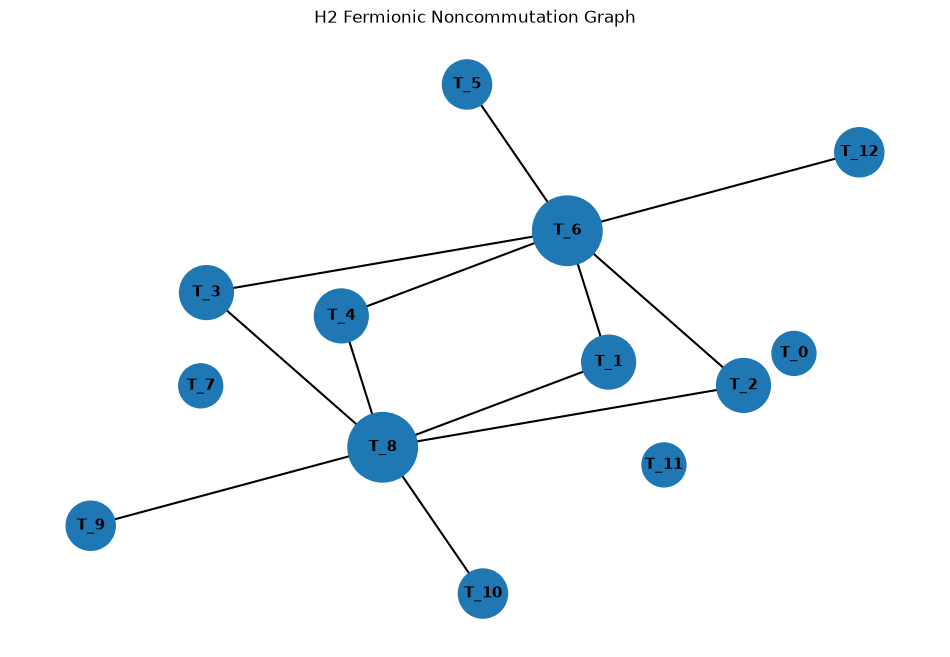

In [4]:
# Cell 2: Build the H2 fermionic noncommutation graph

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from openfermion.transforms import normal_ordered

pd.set_option("display.max_colwidth", None)


def fermionic_commutator(A, B, tol=1e-12):
    """
    Compute [A, B] = AB - BA directly in the fermionic algebra.
    """
    C = normal_ordered(A * B - B * A)
    C.compress(abs_tol=tol)
    return C


def commute(A, B, tol=1e-12):
    """
    Return True if [A, B] = 0.
    """
    C = fermionic_commutator(A, B, tol=tol)
    return len(C.terms) == 0


# ------------------------------------------------------------
# Build noncommutation graph
# ------------------------------------------------------------
# Vertex i = Hermitian fermionic term T_i
# Edge (i, j) exists if [T_i, T_j] != 0

G = nx.Graph()

for i, T in enumerate(hermitian_terms):
    G.add_node(
        i,
        label=f"T_{i}",
        operator=T,
        operator_string=operator_to_string(T),
        number_of_monomials=len(T.terms),
    )

for i in range(len(hermitian_terms)):
    for j in range(i + 1, len(hermitian_terms)):
        Cij = fermionic_commutator(hermitian_terms[i], hermitian_terms[j])

        if len(Cij.terms) != 0:
            G.add_edge(
                i,
                j,
                commutator=Cij,
                commutator_string=operator_to_string(Cij),
            )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

n_vertices = G.number_of_nodes()
n_total_pairs = n_vertices * (n_vertices - 1) // 2
n_noncommuting_pairs = G.number_of_edges()
n_commuting_pairs = n_total_pairs - n_noncommuting_pairs

print("=== Fermionic noncommutation graph summary ===")
print("Number of vertices / fermionic terms:", n_vertices)
print("Number of total unordered pairs:", n_total_pairs)
print("Number of noncommuting pairs / edges:", n_noncommuting_pairs)
print("Number of commuting pairs:", n_commuting_pairs)
print("Is graph bipartite?", nx.is_bipartite(G))


# ------------------------------------------------------------
# Vertex table
# ------------------------------------------------------------

vertex_rows = []

for i, data in G.nodes(data=True):
    vertex_rows.append(
        {
            "vertex": f"T_{i}",
            "degree": G.degree[i],
            "commutes_with_all": G.degree[i] == 0,
            "fermionic_term": data["operator_string"],
        }
    )

vertex_df = pd.DataFrame(vertex_rows)

print("\n=== Vertices: fermionic terms ===")
display(vertex_df)


# ------------------------------------------------------------
# Edge table
# ------------------------------------------------------------

edge_rows = []

for i, j, data in G.edges(data=True):
    edge_rows.append(
        {
            "source": f"T_{i}",
            "target": f"T_{j}",
            "meaning": f"[T_{i}, T_{j}] != 0",
            "commutator": data["commutator_string"],
        }
    )

edge_df = pd.DataFrame(edge_rows)

print("\n=== Edges: noncommuting pairs ===")
display(edge_df)


# ------------------------------------------------------------
# Draw graph
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

pos = nx.kamada_kawai_layout(G)

node_labels = {
    i: f"T_{i}"
    for i in G.nodes()
}

node_sizes = [
    1000 + 250 * G.degree[i]
    for i in G.nodes()
]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes)
nx.draw_networkx_edges(G, pos, width=1.5)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=11, font_weight="bold")

plt.title("H2 Fermionic Noncommutation Graph")
plt.axis("off")
plt.show()

In [5]:
print("Same edge set?")
print(set(G.edges()) == set(G_alpha.edges()))

Same edge set?
True


In [6]:
# Cell 3: Color graph, build commuting blocks, map JW/BK, verify commutation

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from openfermion.ops import FermionOperator
from openfermion.transforms import normal_ordered, jordan_wigner, bravyi_kitaev

pd.set_option("display.max_colwidth", None)


# ------------------------------------------------------------
# 1. Color the noncommutation graph
# ------------------------------------------------------------
# Since edges mean noncommutation, each color class is a commuting group.

coloring = nx.coloring.greedy_color(G, strategy="largest_first")

color_groups = {}

for node, color in coloring.items():
    color_groups.setdefault(color, []).append(node)

for color in color_groups:
    color_groups[color] = sorted(color_groups[color])

color_names = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "gray",
]

color_name = {
    color: color_names[color] if color < len(color_names) else f"color_{color}"
    for color in color_groups
}

num_grouped_terms = sum(len(nodes) for nodes in color_groups.values())

print("Number of fermionic terms / vertices:", G.number_of_nodes())
print("Number of colors / commuting groups:", len(color_groups))
print("Number of grouped terms:", num_grouped_terms)

assert num_grouped_terms == G.number_of_nodes()


# ------------------------------------------------------------
# 2. Verify each color group is mutually commuting
# ------------------------------------------------------------

def verify_commuting_group(nodes, tol=1e-12):
    for i, j in combinations(nodes, 2):
        A = G.nodes[i]["operator"]
        B = G.nodes[j]["operator"]

        if not commute(A, B, tol=tol):
            return False

    return True


group_summary_rows = []

for color, nodes in sorted(color_groups.items()):
    group_summary_rows.append(
        {
            "color_id": color,
            "color_name": color_name[color],
            "number_of_terms": len(nodes),
            "vertices": [f"T_{i}" for i in nodes],
            "verified_mutually_commuting": verify_commuting_group(nodes),
        }
    )

group_summary_df = pd.DataFrame(group_summary_rows)

print("\n=== Commuting groups from graph coloring ===")
display(group_summary_df)


# ------------------------------------------------------------
# 3. Build Hamiltonian pieces by color
# ------------------------------------------------------------

H_by_color = {}

for color, nodes in sorted(color_groups.items()):
    H_color = FermionOperator.zero()

    for node in nodes:
        H_color += G.nodes[node]["operator"]

    H_color = normal_ordered(H_color)
    H_color.compress(abs_tol=1e-12)

    H_by_color[color] = H_color


color_block_rows = []

for color, nodes in sorted(color_groups.items()):
    for local_index, node in enumerate(nodes, start=1):
        color_block_rows.append(
            {
                "color_block": f"H_{color_name[color]}",
                "local_term_name": f"{color_name[color][0].upper()}_{local_index}",
                "vertex": f"T_{node}",
                "fermionic_term": G.nodes[node]["operator_string"],
            }
        )

color_block_df = pd.DataFrame(color_block_rows)

print("\n=== Which T_i belongs to which color block ===")
display(color_block_df)


print("\n=== Hamiltonian split by commuting color groups ===")

for color, H_color in H_by_color.items():
    nodes = color_groups[color]

    print("\n" + "=" * 80)
    print(f"H_{color_name[color]} consists of:")
    print(" + ".join([f"T_{node}" for node in nodes]))

    print(f"\nSummed operator H_{color_name[color]} =")
    print(H_color)


# ------------------------------------------------------------
# 4. Trotter ordering induced by color groups
# ------------------------------------------------------------

trotter_order = []

for color, nodes in sorted(color_groups.items()):
    for node in nodes:
        trotter_order.append(node)

print("\n=== Trotter order by commuting color groups ===")
print([f"T_{i}" for i in trotter_order])


# ------------------------------------------------------------
# 5. Helper functions for JW/BK output
# ------------------------------------------------------------

def sort_qubit_key(term):
    return (len(term), term)


def format_qubit_term(term):
    if term == ():
        return "I"

    return " ".join([f"{pauli}{qubit}" for qubit, pauli in term])


def qubit_coeff_to_str(c, digits=8):
    c = complex(c)
    if abs(c.imag) < 1e-12:
        return f"{c.real:+.{digits}f}"
    return f"{c.real:+.{digits}f}{c.imag:+.{digits}f}j"


def qubit_operator_to_string(op, digits=8):
    pieces = []

    for term, coeff in sorted(op.terms.items(), key=lambda item: sort_qubit_key(item[0])):
        pieces.append(f"{qubit_coeff_to_str(coeff, digits)} {format_qubit_term(term)}")

    if len(pieces) == 0:
        return "0"

    return " + ".join(pieces)


def apply_bk(op, n_qubits):
    try:
        return bravyi_kitaev(op, n_qubits=n_qubits)
    except TypeError:
        return bravyi_kitaev(op, n_qubits)


def qubit_commutator(A, B, tol=1e-12):
    C = A * B - B * A
    C.compress(abs_tol=tol)
    return C


def qubit_commute(A, B, tol=1e-12):
    C = qubit_commutator(A, B, tol=tol)
    return len(C.terms) == 0


n_qubits = molecule.n_qubits

print("\nNumber of qubits / spin orbitals:", n_qubits)


# ------------------------------------------------------------
# 6. Map each fermionic vertex T_i to JW(T_i) and BK(T_i)
# ------------------------------------------------------------

mapped_rows = []

for node in sorted(G.nodes()):
    T_i = G.nodes[node]["operator"]

    JW_T_i = jordan_wigner(T_i)
    JW_T_i.compress(abs_tol=1e-12)

    BK_T_i = apply_bk(T_i, n_qubits=n_qubits)
    BK_T_i.compress(abs_tol=1e-12)

    G.nodes[node]["JW_operator"] = JW_T_i
    G.nodes[node]["BK_operator"] = BK_T_i
    G.nodes[node]["JW_operator_string"] = qubit_operator_to_string(JW_T_i)
    G.nodes[node]["BK_operator_string"] = qubit_operator_to_string(BK_T_i)

    node_color = coloring[node]
    node_color_name = color_name[node_color]

    mapped_rows.append(
        {
            "color": node_color_name,
            "vertex": f"T_{node}",
            "fermionic_term": G.nodes[node]["operator_string"],
            "number_of_JW_Pauli_strings": len(JW_T_i.terms),
            "JW_transform": qubit_operator_to_string(JW_T_i),
            "number_of_BK_Pauli_strings": len(BK_T_i.terms),
            "BK_transform": qubit_operator_to_string(BK_T_i),
        }
    )

mapped_terms_df = pd.DataFrame(mapped_rows)

print("\n=== Fermionic terms mapped to JW and BK ===")
display(mapped_terms_df)


# ------------------------------------------------------------
# 7. Map each color block H_color to JW and BK
# ------------------------------------------------------------

JW_by_color = {}
BK_by_color = {}

block_rows = []

for color, H_color in sorted(H_by_color.items()):
    JW_color = jordan_wigner(H_color)
    JW_color.compress(abs_tol=1e-12)

    BK_color = apply_bk(H_color, n_qubits=n_qubits)
    BK_color.compress(abs_tol=1e-12)

    JW_by_color[color] = JW_color
    BK_by_color[color] = BK_color

    block_rows.append(
        {
            "color_block": f"H_{color_name[color]}",
            "fermionic_vertices": " + ".join([f"T_{node}" for node in color_groups[color]]),
            "number_of_fermionic_terms": len(color_groups[color]),
            "number_of_JW_Pauli_strings": len(JW_color.terms),
            "JW_block": qubit_operator_to_string(JW_color),
            "number_of_BK_Pauli_strings": len(BK_color.terms),
            "BK_block": qubit_operator_to_string(BK_color),
        }
    )

block_map_df = pd.DataFrame(block_rows)

print("\n=== Color blocks mapped to JW and BK ===")
display(block_map_df)


# ------------------------------------------------------------
# 8. Verify same-color terms commute after JW and BK
# ------------------------------------------------------------

verification_rows = []

for color, nodes in sorted(color_groups.items()):
    for i, j in combinations(nodes, 2):
        Ti = G.nodes[i]["operator"]
        Tj = G.nodes[j]["operator"]

        JW_Ti = G.nodes[i]["JW_operator"]
        JW_Tj = G.nodes[j]["JW_operator"]

        BK_Ti = G.nodes[i]["BK_operator"]
        BK_Tj = G.nodes[j]["BK_operator"]

        verification_rows.append(
            {
                "color_group": color_name[color],
                "pair": f"T_{i}, T_{j}",
                "fermionic_commute": commute(Ti, Tj),
                "JW_commute": qubit_commute(JW_Ti, JW_Tj),
                "BK_commute": qubit_commute(BK_Ti, BK_Tj),
            }
        )

verification_df = pd.DataFrame(verification_rows)

print("\n=== Verify commuting groups after JW/BK mapping ===")
display(verification_df)

Number of fermionic terms / vertices: 13
Number of colors / commuting groups: 2
Number of grouped terms: 13

=== Commuting groups from graph coloring ===


,color_id,color_name,number_of_terms,vertices,verified_mutually_commuting
0,0,red,5,"[T_0, T_6, T_7, T_8, T_11]",True
1,1,blue,8,"[T_1, T_2, T_3, T_4, T_5, T_9, T_10, T_12]",True



=== Which T_i belongs to which color block ===


,color_block,local_term_name,vertex,fermionic_term
0,H_red,R_1,T_0,+0.71375399 I
1,H_red,R_2,T_6,-0.18128881 a_1^dagger a_0^dagger a_3 a_2 + -0.18128881 a_3^dagger a_2^dagger a_1 a_0
2,H_red,R_3,T_7,-0.48217929 a_2^dagger a_0^dagger a_2 a_0
3,H_red,R_4,T_8,+0.18128881 a_2^dagger a_1^dagger a_3 a_0 + +0.18128881 a_3^dagger a_0^dagger a_2 a_1
4,H_red,R_5,T_11,-0.48217929 a_3^dagger a_1^dagger a_3 a_1
5,H_blue,B_1,T_1,-1.25246357 a_0^dagger a_0
6,H_blue,B_2,T_2,-1.25246357 a_1^dagger a_1
7,H_blue,B_3,T_3,-0.47594872 a_2^dagger a_2
8,H_blue,B_4,T_4,-0.47594872 a_3^dagger a_3
9,H_blue,B_5,T_5,-0.67448877 a_1^dagger a_0^dagger a_1 a_0



=== Hamiltonian split by commuting color groups ===

H_red consists of:
T_0 + T_6 + T_7 + T_8 + T_11

Summed operator H_red =
0.7137539936876182 [] +
-0.18128880821149587 [1^ 0^ 3 2] +
-0.48217928821207157 [2^ 0^ 2 0] +
0.18128880821149587 [2^ 1^ 3 0] +
0.18128880821149587 [3^ 0^ 2 1] +
-0.48217928821207157 [3^ 1^ 3 1] +
-0.18128880821149587 [3^ 2^ 1 0]

H_blue consists of:
T_1 + T_2 + T_3 + T_4 + T_5 + T_9 + T_10 + T_12

Summed operator H_blue =
-1.2524635735648986 [0^ 0] +
-0.6744887663568376 [1^ 0^ 1 0] +
-1.2524635735648986 [1^ 1] +
-0.6634680964235674 [2^ 1^ 2 1] +
-0.47594871522096466 [2^ 2] +
-0.6634680964235674 [3^ 0^ 3 0] +
-0.6973937674230251 [3^ 2^ 3 2] +
-0.47594871522096466 [3^ 3]

=== Trotter order by commuting color groups ===
['T_0', 'T_6', 'T_7', 'T_8', 'T_11', 'T_1', 'T_2', 'T_3', 'T_4', 'T_5', 'T_9', 'T_10', 'T_12']

Number of qubits / spin orbitals: 4

=== Fermionic terms mapped to JW and BK ===


,color,vertex,fermionic_term,number_of_JW_Pauli_strings,JW_transform,number_of_BK_Pauli_strings,BK_transform
0,red,T_0,+0.71375399 I,1,+0.71375399 I,1,+0.71375399 I
1,blue,T_1,-1.25246357 a_0^dagger a_0,2,-0.62623179 I + +0.62623179 Z0,2,-0.62623179 I + +0.62623179 Z0
2,blue,T_2,-1.25246357 a_1^dagger a_1,2,-0.62623179 I + +0.62623179 Z1,2,-0.62623179 I + +0.62623179 Z0 Z1
3,blue,T_3,-0.47594872 a_2^dagger a_2,2,-0.23797436 I + +0.23797436 Z2,2,-0.23797436 I + +0.23797436 Z2
4,blue,T_4,-0.47594872 a_3^dagger a_3,2,-0.23797436 I + +0.23797436 Z3,2,-0.23797436 I + +0.23797436 Z1 Z2 Z3
5,blue,T_5,-0.67448877 a_1^dagger a_0^dagger a_1 a_0,4,+0.16862219 I + -0.16862219 Z0 + -0.16862219 Z1 + +0.16862219 Z0 Z1,4,+0.16862219 I + -0.16862219 Z0 + +0.16862219 Z1 + -0.16862219 Z0 Z1
6,red,T_6,-0.18128881 a_1^dagger a_0^dagger a_3 a_2 + -0.18128881 a_3^dagger a_2^dagger a_1 a_0,8,+0.02266110 X0 X1 X2 X3 + -0.02266110 X0 X1 Y2 Y3 + +0.02266110 X0 Y1 X2 Y3 + +0.02266110 X0 Y1 Y2 X3 + +0.02266110 Y0 X1 X2 Y3 + +0.02266110 Y0 X1 Y2 X3 + -0.02266110 Y0 Y1 X2 X3 + +0.02266110 Y0 Y1 Y2 Y3,8,+0.02266110 X0 X2 + +0.02266110 Y0 Y2 + +0.02266110 X0 Z1 X2 + +0.02266110 X0 X2 Z3 + +0.02266110 Y0 Z1 Y2 + +0.02266110 Y0 Y2 Z3 + +0.02266110 X0 Z1 X2 Z3 + +0.02266110 Y0 Z1 Y2 Z3
7,red,T_7,-0.48217929 a_2^dagger a_0^dagger a_2 a_0,4,+0.12054482 I + -0.12054482 Z0 + -0.12054482 Z2 + +0.12054482 Z0 Z2,4,+0.12054482 I + -0.12054482 Z0 + -0.12054482 Z2 + +0.12054482 Z0 Z2
8,red,T_8,+0.18128881 a_2^dagger a_1^dagger a_3 a_0 + +0.18128881 a_3^dagger a_0^dagger a_2 a_1,8,-0.02266110 X0 X1 X2 X3 + -0.02266110 X0 X1 Y2 Y3 + -0.02266110 X0 Y1 X2 Y3 + +0.02266110 X0 Y1 Y2 X3 + +0.02266110 Y0 X1 X2 Y3 + -0.02266110 Y0 X1 Y2 X3 + -0.02266110 Y0 Y1 X2 X3 + -0.02266110 Y0 Y1 Y2 Y3,8,-0.02266110 X0 X2 + -0.02266110 Y0 Y2 + +0.02266110 X0 Z1 X2 + -0.02266110 X0 X2 Z3 + +0.02266110 Y0 Z1 Y2 + -0.02266110 Y0 Y2 Z3 + +0.02266110 X0 Z1 X2 Z3 + +0.02266110 Y0 Z1 Y2 Z3
9,blue,T_9,-0.66346810 a_3^dagger a_0^dagger a_3 a_0,4,+0.16586702 I + -0.16586702 Z0 + -0.16586702 Z3 + +0.16586702 Z0 Z3,4,+0.16586702 I + -0.16586702 Z0 + -0.16586702 Z1 Z2 Z3 + +0.16586702 Z0 Z1 Z2 Z3



=== Color blocks mapped to JW and BK ===


,color_block,fermionic_vertices,number_of_fermionic_terms,number_of_JW_Pauli_strings,JW_block,number_of_BK_Pauli_strings,BK_block
0,H_red,T_0 + T_6 + T_7 + T_8 + T_11,5,11,+0.95484364 I + -0.12054482 Z0 + -0.12054482 Z1 + -0.12054482 Z2 + -0.12054482 Z3 + +0.12054482 Z0 Z2 + +0.12054482 Z1 Z3 + -0.04532220 X0 X1 Y2 Y3 + +0.04532220 X0 Y1 Y2 X3 + +0.04532220 Y0 X1 X2 Y3 + -0.04532220 Y0 Y1 X2 X3,11,+0.95484364 I + -0.12054482 Z0 + -0.12054482 Z2 + -0.12054482 Z0 Z1 + +0.12054482 Z0 Z2 + +0.04532220 X0 Z1 X2 + +0.04532220 Y0 Z1 Y2 + +0.12054482 Z0 Z2 Z3 + -0.12054482 Z1 Z2 Z3 + +0.04532220 X0 Z1 X2 Z3 + +0.04532220 Y0 Z1 Y2 Z3
1,H_blue,T_1 + T_2 + T_3 + T_4 + T_5 + T_9 + T_10 + T_12,8,9,-1.05370761 I + +0.29174257 Z0 + +0.29174257 Z1 + -0.10224111 Z2 + -0.10224111 Z3 + +0.16862219 Z0 Z1 + +0.16586702 Z0 Z3 + +0.16586702 Z1 Z2 + +0.17434844 Z2 Z3,9,-1.05370761 I + +0.29174257 Z0 + +0.16862219 Z1 + -0.10224111 Z2 + +0.29174257 Z0 Z1 + +0.17434844 Z1 Z3 + +0.16586702 Z0 Z1 Z2 + -0.10224111 Z1 Z2 Z3 + +0.16586702 Z0 Z1 Z2 Z3



=== Verify commuting groups after JW/BK mapping ===


,color_group,pair,fermionic_commute,JW_commute,BK_commute
0,red,"T_0, T_6",True,True,True
1,red,"T_0, T_7",True,True,True
2,red,"T_0, T_8",True,True,True
3,red,"T_0, T_11",True,True,True
4,red,"T_6, T_7",True,True,True
5,red,"T_6, T_8",True,True,True
6,red,"T_6, T_11",True,True,True
7,red,"T_7, T_8",True,True,True
8,red,"T_7, T_11",True,True,True
9,red,"T_8, T_11",True,True,True


In [7]:
# Find duplicated JW Pauli strings across fermionic terms T_i

from collections import defaultdict
import pandas as pd

pauli_usage = defaultdict(list)

for node in sorted(G.nodes()):
    JW_T = G.nodes[node]["JW_operator"]

    for pauli_key, coeff in JW_T.terms.items():
        pauli_string = format_qubit_term(pauli_key)

        pauli_usage[pauli_string].append(
            {
                "vertex": f"T_{node}",
                "coefficient": coeff,
                "fermionic_term": G.nodes[node]["operator_string"],
            }
        )

duplicate_rows = []

for pauli_string, appearances in pauli_usage.items():
    if len(appearances) > 1:
        duplicate_rows.append(
            {
                "JW_Pauli_string": pauli_string,
                "number_of_appearances": len(appearances),
                "appears_in_vertices": [x["vertex"] for x in appearances],
                "coefficients": [x["coefficient"] for x in appearances],
            }
        )

duplicate_jw_df = pd.DataFrame(duplicate_rows)
duplicate_jw_df = duplicate_jw_df.sort_values(
    "number_of_appearances",
    ascending=False
).reset_index(drop=True)

print("Total JW Pauli-string appearances:", sum(len(G.nodes[node]["JW_operator"].terms) for node in G.nodes()))
print("Number of unique JW Pauli strings:", len(pauli_usage))
print("Number of duplicated JW Pauli strings:", len(duplicate_jw_df))

display(duplicate_jw_df)

Total JW Pauli-string appearances: 49
Number of unique JW Pauli strings: 19
Number of duplicated JW Pauli strings: 13


,JW_Pauli_string,number_of_appearances,appears_in_vertices,coefficients
0,I,11,"[T_0, T_1, T_2, T_3, T_4, T_5, T_7, T_9, T_10, T_11, T_12]","[0.7137539936876182, -0.6262317867824493, -0.6262317867824493, -0.23797435761048233, -0.23797435761048233, 0.1686221915892094, 0.12054482205301789, 0.16586702410589185, 0.16586702410589185, 0.12054482205301789, 0.17434844185575626]"
1,Z0,4,"[T_1, T_5, T_7, T_9]","[0.6262317867824493, -0.1686221915892094, -0.12054482205301789, -0.16586702410589185]"
2,Z1,4,"[T_2, T_5, T_10, T_11]","[0.6262317867824493, -0.1686221915892094, -0.16586702410589185, -0.12054482205301789]"
3,Z2,4,"[T_3, T_7, T_10, T_12]","[0.23797435761048233, -0.12054482205301789, -0.16586702410589185, -0.17434844185575626]"
4,Z3,4,"[T_4, T_9, T_11, T_12]","[0.23797435761048233, -0.16586702410589185, -0.12054482205301789, -0.17434844185575626]"
5,Y0 X1 Y2 X3,2,"[T_6, T_8]","[0.022661101026436984, -0.022661101026436984]"
6,Y0 X1 X2 Y3,2,"[T_6, T_8]","[0.022661101026436984, 0.022661101026436984]"
7,X0 X1 X2 X3,2,"[T_6, T_8]","[0.022661101026436984, -0.022661101026436984]"
8,X0 X1 Y2 Y3,2,"[T_6, T_8]","[-0.022661101026436984, -0.022661101026436984]"
9,Y0 Y1 X2 X3,2,"[T_6, T_8]","[-0.022661101026436984, -0.022661101026436984]"


In [8]:
# Compute Pauli-duplication ratio for JW and BK

from collections import defaultdict
import pandas as pd

from openfermion.ops import FermionOperator
from openfermion.transforms import jordan_wigner, bravyi_kitaev, normal_ordered


def pauli_support(qubit_op, tol=1e-12, include_identity=True):
    """
    Return the set of Pauli strings with nonzero coefficients.
    """
    qubit_op.compress(abs_tol=tol)

    support = set()

    for pauli_key, coeff in qubit_op.terms.items():
        if abs(coeff) <= tol:
            continue

        if not include_identity and pauli_key == ():
            continue

        support.add(pauli_key)

    return support


def map_fermion_to_qubit(op, mapping="JW", n_qubits=None):
    """
    Map a FermionOperator to a QubitOperator using JW or BK.
    """
    mapping = mapping.upper()

    if mapping == "JW":
        qop = jordan_wigner(op)

    elif mapping == "BK":
        if n_qubits is None:
            raise ValueError("n_qubits is required for BK.")

        try:
            qop = bravyi_kitaev(op, n_qubits=n_qubits)
        except TypeError:
            qop = bravyi_kitaev(op, n_qubits)

    else:
        raise ValueError("mapping must be 'JW' or 'BK'.")

    qop.compress(abs_tol=1e-12)
    return qop


def pauli_duplication_ratio(
    fermionic_terms,
    mapping="JW",
    n_qubits=None,
    include_identity=True,
    tol=1e-12,
):
    """
    Compute

        sum_alpha #mapping(H_alpha) / #mapping(H)

    where H = sum_alpha H_alpha.

    Also returns a duplicate-use table.
    """

    H_full = FermionOperator.zero()

    numerator = 0
    union_support = set()
    pauli_usage = defaultdict(list)

    for alpha, H_alpha in enumerate(fermionic_terms):
        H_full += H_alpha

        Q_alpha = map_fermion_to_qubit(
            H_alpha,
            mapping=mapping,
            n_qubits=n_qubits,
        )

        support_alpha = pauli_support(
            Q_alpha,
            tol=tol,
            include_identity=include_identity,
        )

        numerator += len(support_alpha)
        union_support |= support_alpha

        for pauli_key, coeff in Q_alpha.terms.items():
            if abs(coeff) <= tol:
                continue

            if not include_identity and pauli_key == ():
                continue

            pauli_usage[pauli_key].append(
                {
                    "vertex": f"T_{alpha}",
                    "coefficient": coeff,
                }
            )

    H_full = normal_ordered(H_full)
    H_full.compress(abs_tol=tol)

    Q_full = map_fermion_to_qubit(
        H_full,
        mapping=mapping,
        n_qubits=n_qubits,
    )

    full_support = pauli_support(
        Q_full,
        tol=tol,
        include_identity=include_identity,
    )

    denominator = len(full_support)

    duplication_ratio = numerator / denominator
    union_ratio = numerator / len(union_support)

    summary_df = pd.DataFrame(
        [
            {
                "mapping": mapping.upper(),
                "include_identity": include_identity,
                "sum_alpha_number_of_Pauli_strings": numerator,
                "number_of_unique_Pauli_strings_before_cancellation": len(union_support),
                "number_of_Pauli_strings_in_full_H": denominator,
                "duplication_ratio": duplication_ratio,
                "raw_reuse_ratio_before_cancellation": union_ratio,
            }
        ]
    )

    duplicate_rows = []

    for pauli_key, appearances in pauli_usage.items():
        if len(appearances) <= 1:
            continue

        combined_coeff = Q_full.terms.get(pauli_key, 0.0)

        duplicate_rows.append(
            {
                "Pauli_string": format_qubit_term(pauli_key),
                "number_of_appearances": len(appearances),
                "appears_in_vertices": [x["vertex"] for x in appearances],
                "individual_coefficients": [complex(x["coefficient"]) for x in appearances],
                "combined_coefficient_in_full_H": complex(combined_coeff),
                "survives_in_full_H": abs(combined_coeff) > tol,
            }
        )

    duplicate_df = pd.DataFrame(duplicate_rows)

    if len(duplicate_df) > 0:
        duplicate_df = duplicate_df.sort_values(
            "number_of_appearances",
            ascending=False,
        ).reset_index(drop=True)

    return summary_df, duplicate_df


# ------------------------------------------------------------
# Run for JW
# ------------------------------------------------------------

n_qubits = molecule.n_qubits

jw_summary_df, jw_duplicate_df = pauli_duplication_ratio(
    hermitian_terms,
    mapping="JW",
    n_qubits=n_qubits,
    include_identity=True,
)

print("=== JW Pauli-duplication ratio ===")
display(jw_summary_df)

print("\n=== Duplicated JW Pauli strings ===")
display(jw_duplicate_df)


# ------------------------------------------------------------
# Optional: run for BK too
# ------------------------------------------------------------

bk_summary_df, bk_duplicate_df = pauli_duplication_ratio(
    hermitian_terms,
    mapping="BK",
    n_qubits=n_qubits,
    include_identity=True,
)

print("=== BK Pauli-duplication ratio ===")
display(bk_summary_df)

print("\n=== Duplicated BK Pauli strings ===")
display(bk_duplicate_df)

=== JW Pauli-duplication ratio ===


,mapping,include_identity,sum_alpha_number_of_Pauli_strings,number_of_unique_Pauli_strings_before_cancellation,number_of_Pauli_strings_in_full_H,duplication_ratio,raw_reuse_ratio_before_cancellation
0,JW,True,49,19,15,3.266667,2.578947



=== Duplicated JW Pauli strings ===


,Pauli_string,number_of_appearances,appears_in_vertices,individual_coefficients,combined_coefficient_in_full_H,survives_in_full_H
0,I,11,"[T_0, T_1, T_2, T_3, T_4, T_5, T_7, T_9, T_10, T_11, T_12]","[(0.7137539936876182+0j), (-0.6262317867824493+0j), (-0.6262317867824493+0j), (-0.23797435761048233+0j), (-0.23797435761048233+0j), (0.1686221915892094+0j), (0.12054482205301789+0j), (0.16586702410589185+0j), (0.16586702410589185+0j), (0.12054482205301789+0j), (0.17434844185575626+0j)]",-0.098864+0.000000j,True
1,Z0,4,"[T_1, T_5, T_7, T_9]","[(0.6262317867824493+0j), (-0.1686221915892094+0j), (-0.12054482205301789+0j), (-0.16586702410589185+0j)]",0.171198+0.000000j,True
2,Z1,4,"[T_2, T_5, T_10, T_11]","[(0.6262317867824493+0j), (-0.1686221915892094+0j), (-0.16586702410589185+0j), (-0.12054482205301789+0j)]",0.171198+0.000000j,True
3,Z2,4,"[T_3, T_7, T_10, T_12]","[(0.23797435761048233+0j), (-0.12054482205301789+0j), (-0.16586702410589185+0j), (-0.17434844185575626+0j)]",-0.222786+0.000000j,True
4,Z3,4,"[T_4, T_9, T_11, T_12]","[(0.23797435761048233+0j), (-0.16586702410589185+0j), (-0.12054482205301789+0j), (-0.17434844185575626+0j)]",-0.222786+0.000000j,True
5,Y0 X1 Y2 X3,2,"[T_6, T_8]","[(0.022661101026436984+0j), (-0.022661101026436984+0j)]",0.000000+0.000000j,False
6,Y0 X1 X2 Y3,2,"[T_6, T_8]","[(0.022661101026436984+0j), (0.022661101026436984+0j)]",0.045322+0.000000j,True
7,X0 X1 X2 X3,2,"[T_6, T_8]","[(0.022661101026436984+0j), (-0.022661101026436984+0j)]",0.000000+0.000000j,False
8,X0 X1 Y2 Y3,2,"[T_6, T_8]","[(-0.022661101026436984+0j), (-0.022661101026436984+0j)]",-0.045322+0.000000j,True
9,Y0 Y1 X2 X3,2,"[T_6, T_8]","[(-0.022661101026436984+0j), (-0.022661101026436984+0j)]",-0.045322+0.000000j,True


=== BK Pauli-duplication ratio ===


,mapping,include_identity,sum_alpha_number_of_Pauli_strings,number_of_unique_Pauli_strings_before_cancellation,number_of_Pauli_strings_in_full_H,duplication_ratio,raw_reuse_ratio_before_cancellation
0,BK,True,49,19,15,3.266667,2.578947



=== Duplicated BK Pauli strings ===


,Pauli_string,number_of_appearances,appears_in_vertices,individual_coefficients,combined_coefficient_in_full_H,survives_in_full_H
0,I,11,"[T_0, T_1, T_2, T_3, T_4, T_5, T_7, T_9, T_10, T_11, T_12]","[(0.7137539936876182+0j), (-0.6262317867824493+0j), (-0.6262317867824493+0j), (-0.23797435761048233+0j), (-0.23797435761048233+0j), (0.1686221915892094+0j), (0.12054482205301789+0j), (0.16586702410589185+0j), (0.16586702410589185+0j), (0.12054482205301789+0j), (0.17434844185575626+0j)]",-0.098864+0.000000j,True
1,Z0,4,"[T_1, T_5, T_7, T_9]","[(0.6262317867824493+0j), (-0.1686221915892094+0j), (-0.12054482205301789+0j), (-0.16586702410589185+0j)]",0.171198+0.000000j,True
2,Z0 Z1,4,"[T_2, T_5, T_10, T_11]","[(0.6262317867824493+0j), (-0.1686221915892094+0j), (-0.16586702410589185+0j), (-0.12054482205301789+0j)]",0.171198+0.000000j,True
3,Z2,4,"[T_3, T_7, T_10, T_12]","[(0.23797435761048233+0j), (-0.12054482205301789+0j), (-0.16586702410589185+0j), (-0.17434844185575626+0j)]",-0.222786+0.000000j,True
4,Z1 Z2 Z3,4,"[T_4, T_9, T_11, T_12]","[(0.23797435761048233+0j), (-0.16586702410589185+0j), (-0.12054482205301789+0j), (-0.17434844185575626+0j)]",-0.222786+0.000000j,True
5,Y0 Y2,2,"[T_6, T_8]","[(0.022661101026436984+0j), (-0.022661101026436984+0j)]",0.000000+0.000000j,False
6,Y0 Z1 Y2 Z3,2,"[T_6, T_8]","[(0.022661101026436984+0j), (0.022661101026436984+0j)]",0.045322+0.000000j,True
7,X0 X2,2,"[T_6, T_8]","[(0.022661101026436984+0j), (-0.022661101026436984+0j)]",0.000000+0.000000j,False
8,X0 Z1 X2 Z3,2,"[T_6, T_8]","[(0.022661101026436984+0j), (0.022661101026436984+0j)]",0.045322+0.000000j,True
9,X0 Z1 X2,2,"[T_6, T_8]","[(0.022661101026436984+0j), (0.022661101026436984+0j)]",0.045322+0.000000j,True


In [9]:
# New Cell 1: Fermionic-term Trotter error helper functions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import expm
from openfermion.linalg import get_sparse_operator
from openfermion.transforms import jordan_wigner


def qubit_operator_matrix(qubit_op, n_qubits):
    """
    Convert an OpenFermion QubitOperator into a dense matrix.
    H2 is small enough for dense matrices.
    """
    qubit_op.compress(abs_tol=1e-12)
    return get_sparse_operator(qubit_op, n_qubits=n_qubits).toarray()


def map_fermion_operator_to_matrix(fermion_op, mapping="JW"):
    """
    Map a FermionOperator to JW or BK and return its dense matrix.
    """
    mapping = mapping.upper()

    if mapping == "JW":
        qubit_op = jordan_wigner(fermion_op)

    elif mapping == "BK":
        qubit_op = apply_bk(fermion_op, n_qubits=n_qubits)

    else:
        raise ValueError("mapping must be 'JW' or 'BK'.")

    qubit_op.compress(abs_tol=1e-12)
    return qubit_operator_matrix(qubit_op, n_qubits=n_qubits)


def exact_unitary(H_matrix, t):
    """
    Exact evolution U_exact(t) = exp(-i H t).
    """
    return expm(-1j * t * H_matrix)


def first_order_trotter_unitary(term_matrices, t):
    """
    First-order Trotter product:

        U_Trot(t) = prod_alpha exp(-i H_alpha t)

    The terms are applied in the order provided.
    """
    dim = term_matrices[0].shape[0]
    U = np.eye(dim, dtype=complex)

    for H_alpha in term_matrices:
        U = expm(-1j * t * H_alpha) @ U

    return U


def operator_norm_error(U_trotter, U_exact):
    """
    Operator-norm Trotter error.
    """
    return np.linalg.norm(U_trotter - U_exact, ord=2)


def ground_state_vector(H_matrix):
    """
    Use the exact ground state as the state for state-based error.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
    ground_index = np.argmin(eigenvalues)
    return eigenvectors[:, ground_index]


def state_based_error(U_trotter, U_exact, psi0):
    """
    State-dependent Trotter error.
    """
    return np.linalg.norm((U_trotter - U_exact) @ psi0)


def compute_trotter_errors(H_matrix, term_matrices, t):
    """
    Compute both operator-norm error and state-based error.
    """
    U_exact = exact_unitary(H_matrix, t)
    U_trotter = first_order_trotter_unitary(term_matrices, t)

    psi0 = ground_state_vector(H_matrix)

    return {
        "operator_norm_error": operator_norm_error(U_trotter, U_exact),
        "state_based_error": state_based_error(U_trotter, U_exact, psi0),
    }

In [ ]:
# New Cell 2: Build fermionic Trotter pieces

# ------------------------------------------------------------
# Full Hamiltonian matrices
# ------------------------------------------------------------

H_JW_matrix = map_fermion_operator_to_matrix(Hf, mapping="JW")
H_BK_matrix = map_fermion_operator_to_matrix(Hf, mapping="BK")


# ------------------------------------------------------------
# Ordering 1: individual fermionic terms in color-induced order
# ------------------------------------------------------------

JW_fermionic_term_matrices = [
    map_fermion_operator_to_matrix(G.nodes[node]["operator"], mapping="JW")
    for node in trotter_order
]

BK_fermionic_term_matrices = [
    map_fermion_operator_to_matrix(G.nodes[node]["operator"], mapping="BK")
    for node in trotter_order
]


# ------------------------------------------------------------
# Ordering 2: commuting color blocks
# ------------------------------------------------------------
# Each H_by_color[color] is a sum of mutually commuting fermionic terms.

JW_color_block_matrices = [
    map_fermion_operator_to_matrix(H_by_color[color], mapping="JW")
    for color in sorted(H_by_color)
]

BK_color_block_matrices = [
    map_fermion_operator_to_matrix(H_by_color[color], mapping="BK")
    for color in sorted(H_by_color)
]


print("Number of individual fermionic terms:", len(JW_fermionic_term_matrices))
print("Number of color blocks:", len(JW_color_block_matrices))
print("Matrix dimension:", H_JW_matrix.shape)

Number of individual fermionic terms: 13
Number of color blocks: 2
Matrix dimension: (16, 16)


In [11]:
# New Cell 3: Fixed-time fermionic Trotter error

t = 1.0

experiments = [
    {
        "mapping": "JW",
        "ordering": "fermionic-term order",
        "H_matrix": H_JW_matrix,
        "term_matrices": JW_fermionic_term_matrices,
    },
    {
        "mapping": "BK",
        "ordering": "fermionic-term order",
        "H_matrix": H_BK_matrix,
        "term_matrices": BK_fermionic_term_matrices,
    },
    {
        "mapping": "JW",
        "ordering": "color-block order",
        "H_matrix": H_JW_matrix,
        "term_matrices": JW_color_block_matrices,
    },
    {
        "mapping": "BK",
        "ordering": "color-block order",
        "H_matrix": H_BK_matrix,
        "term_matrices": BK_color_block_matrices,
    },
]

rows = []

for exp in experiments:
    errors = compute_trotter_errors(
        H_matrix=exp["H_matrix"],
        term_matrices=exp["term_matrices"],
        t=t,
    )

    rows.append(
        {
            "mapping": exp["mapping"],
            "ordering": exp["ordering"],
            "time_t": t,
            "number_of_exponentials": len(exp["term_matrices"]),
            "operator_norm_error": errors["operator_norm_error"],
            "state_based_error": errors["state_based_error"],
        }
    )

fermionic_trotter_error_df = pd.DataFrame(rows)

print("=== Fermionic Trotter error at fixed time ===")
display(fermionic_trotter_error_df)

=== Fermionic Trotter error at fixed time ===


,mapping,ordering,time_t,number_of_exponentials,operator_norm_error,state_based_error
0,JW,fermionic-term order,1.0,13,0.132779,0.132779
1,BK,fermionic-term order,1.0,13,0.132779,0.132779
2,JW,color-block order,1.0,2,0.132779,0.132779
3,BK,color-block order,1.0,2,0.132779,0.132779


=== Fermionic Trotter error over time ===


,mapping,ordering,time_t,operator_norm_error,state_based_error
0,JW,fermionic-term order,0.0,0.000000,0.000000
1,BK,fermionic-term order,0.0,0.000000,0.000000
2,JW,color-block order,0.0,0.000000,0.000000
3,BK,color-block order,0.0,0.000000,0.000000
4,JW,fermionic-term order,0.1,0.001427,0.001427
...,...,...,...,...,...
79,BK,color-block order,1.9,0.394398,0.394398
80,JW,fermionic-term order,2.0,0.424249,0.424249
81,BK,fermionic-term order,2.0,0.424249,0.424249
82,JW,color-block order,2.0,0.424249,0.424249


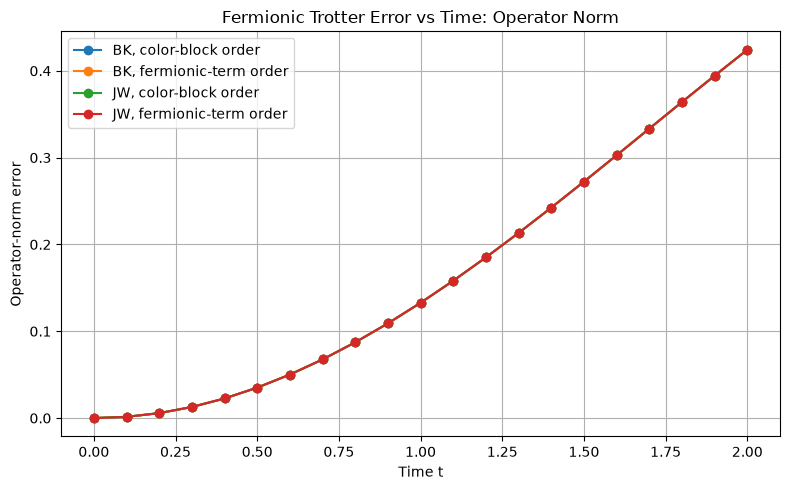

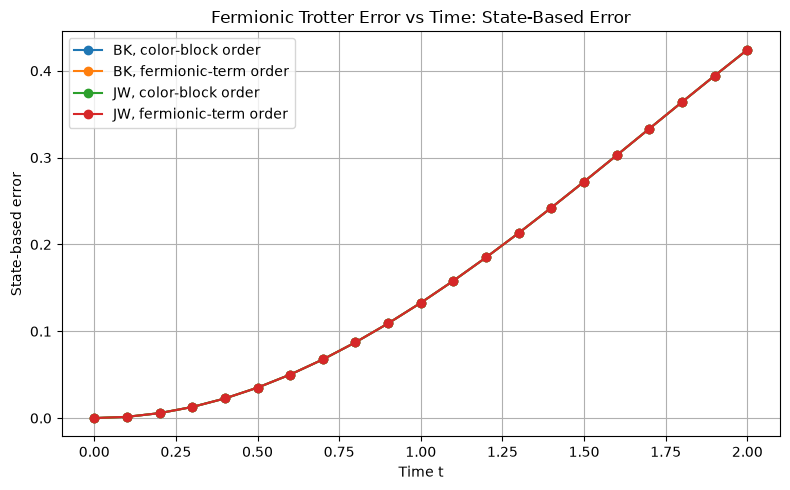

In [12]:
# New Cell 4: Fermionic Trotter error vs time

t_values = np.linspace(0.0, 2.0, 21)

time_rows = []

for t in t_values:
    for exp in experiments:
        errors = compute_trotter_errors(
            H_matrix=exp["H_matrix"],
            term_matrices=exp["term_matrices"],
            t=t,
        )

        time_rows.append(
            {
                "mapping": exp["mapping"],
                "ordering": exp["ordering"],
                "time_t": t,
                "operator_norm_error": errors["operator_norm_error"],
                "state_based_error": errors["state_based_error"],
            }
        )

fermionic_time_error_df = pd.DataFrame(time_rows)

print("=== Fermionic Trotter error over time ===")
display(fermionic_time_error_df)


# ------------------------------------------------------------
# Operator-norm error plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for (mapping, ordering), group in fermionic_time_error_df.groupby(["mapping", "ordering"]):
    label = f"{mapping}, {ordering}"
    plt.plot(
        group["time_t"],
        group["operator_norm_error"],
        marker="o",
        label=label,
    )

plt.xlabel("Time t")
plt.ylabel("Operator-norm error")
plt.title("Fermionic Trotter Error vs Time: Operator Norm")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# State-based error plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for (mapping, ordering), group in fermionic_time_error_df.groupby(["mapping", "ordering"]):
    label = f"{mapping}, {ordering}"
    plt.plot(
        group["time_t"],
        group["state_based_error"],
        marker="o",
        label=label,
    )

plt.xlabel("Time t")
plt.ylabel("State-based error")
plt.title("Fermionic Trotter Error vs Time: State-Based Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

=== Fermionic Trotter error for multiple orderings ===


,mapping,ordering,time_t,operator_norm_error,state_based_error,number_of_exponentials
0,JW,raw fermionic order,0.0,0.000000,0.000000,13
1,BK,raw fermionic order,0.0,0.000000,0.000000,13
2,JW,reversed fermionic order,0.0,0.000000,0.000000,13
3,BK,reversed fermionic order,0.0,0.000000,0.000000,13
4,JW,random fermionic order,0.0,0.000000,0.000000,13
...,...,...,...,...,...,...
205,BK,random fermionic order,2.0,0.184657,0.184657,13
206,JW,color-induced fermionic order,2.0,0.424249,0.424249,13
207,BK,color-induced fermionic order,2.0,0.424249,0.424249,13
208,JW,color-block order,2.0,0.424249,0.424249,2


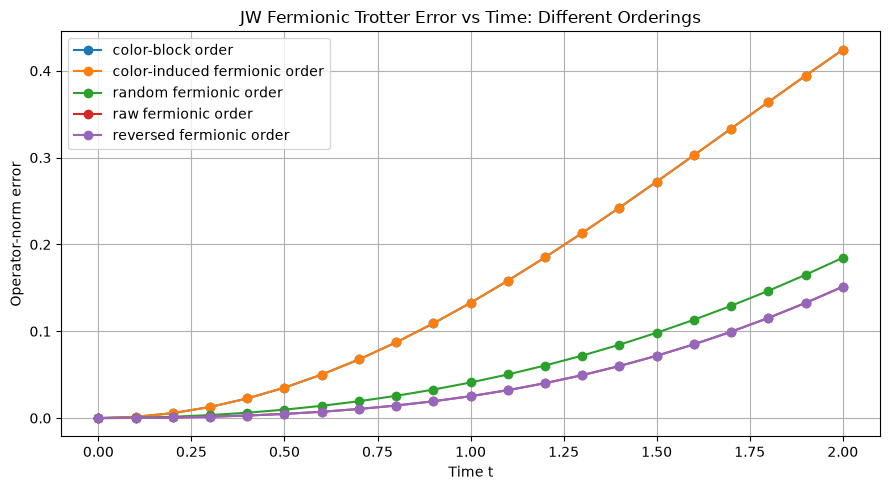

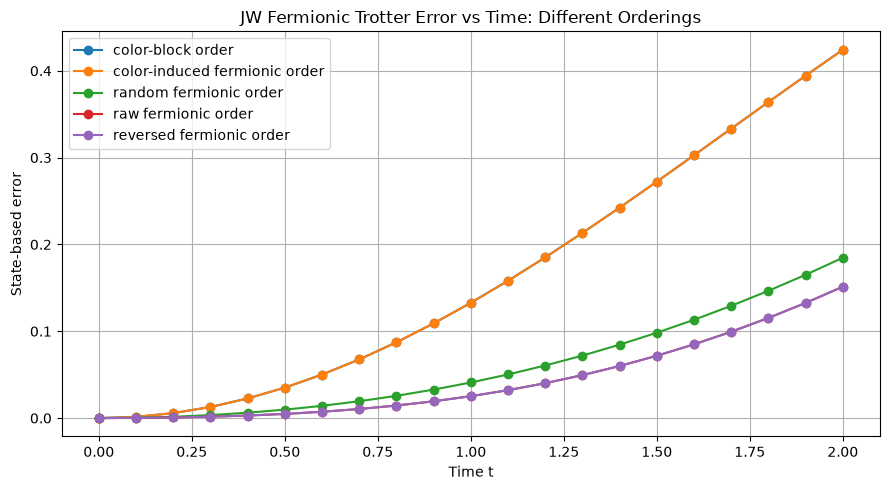

=== Summary at t = 2.0 ===


,mapping,ordering,time_t,operator_norm_error,state_based_error,number_of_exponentials
201,BK,raw fermionic order,2.0,0.151296,0.151296,13
203,BK,reversed fermionic order,2.0,0.151296,0.151296,13
200,JW,raw fermionic order,2.0,0.151296,0.151296,13
202,JW,reversed fermionic order,2.0,0.151296,0.151296,13
205,BK,random fermionic order,2.0,0.184657,0.184657,13
204,JW,random fermionic order,2.0,0.184657,0.184657,13
207,BK,color-induced fermionic order,2.0,0.424249,0.424249,13
206,JW,color-induced fermionic order,2.0,0.424249,0.424249,13
209,BK,color-block order,2.0,0.424249,0.424249,2
208,JW,color-block order,2.0,0.424249,0.424249,2


In [13]:
# New Cell 5: Compare multiple fermionic orderings

import random

def fermionic_term_matrices_from_order(order, mapping="JW"):
    """
    Convert a list of fermionic graph node indices into mapped Hamiltonian matrices.
    """
    return [
        map_fermion_operator_to_matrix(G.nodes[node]["operator"], mapping=mapping)
        for node in order
    ]


# ------------------------------------------------------------
# Define several fermionic orderings
# ------------------------------------------------------------

raw_order = list(G.nodes())
reversed_order = list(reversed(raw_order))

random.seed(7)
random_order = raw_order.copy()
random.shuffle(random_order)

color_induced_order = list(trotter_order)


ordering_dict = {
    "raw fermionic order": raw_order,
    "reversed fermionic order": reversed_order,
    "random fermionic order": random_order,
    "color-induced fermionic order": color_induced_order,
}


# ------------------------------------------------------------
# Build experiment list
# ------------------------------------------------------------

ordering_experiments = []

for ordering_name, order in ordering_dict.items():
    ordering_experiments.append(
        {
            "mapping": "JW",
            "ordering": ordering_name,
            "H_matrix": H_JW_matrix,
            "term_matrices": fermionic_term_matrices_from_order(order, mapping="JW"),
        }
    )

    ordering_experiments.append(
        {
            "mapping": "BK",
            "ordering": ordering_name,
            "H_matrix": H_BK_matrix,
            "term_matrices": fermionic_term_matrices_from_order(order, mapping="BK"),
        }
    )


# Also include color-block order
ordering_experiments.append(
    {
        "mapping": "JW",
        "ordering": "color-block order",
        "H_matrix": H_JW_matrix,
        "term_matrices": JW_color_block_matrices,
    }
)

ordering_experiments.append(
    {
        "mapping": "BK",
        "ordering": "color-block order",
        "H_matrix": H_BK_matrix,
        "term_matrices": BK_color_block_matrices,
    }
)


# ------------------------------------------------------------
# Compute errors over time
# ------------------------------------------------------------

t_values = np.linspace(0.0, 2.0, 21)

ordering_time_rows = []

for t in t_values:
    for exp in ordering_experiments:
        errors = compute_trotter_errors(
            H_matrix=exp["H_matrix"],
            term_matrices=exp["term_matrices"],
            t=t,
        )

        ordering_time_rows.append(
            {
                "mapping": exp["mapping"],
                "ordering": exp["ordering"],
                "time_t": t,
                "operator_norm_error": errors["operator_norm_error"],
                "state_based_error": errors["state_based_error"],
                "number_of_exponentials": len(exp["term_matrices"]),
            }
        )

ordering_time_error_df = pd.DataFrame(ordering_time_rows)

print("=== Fermionic Trotter error for multiple orderings ===")
display(ordering_time_error_df)


# ------------------------------------------------------------
# Plot only JW first, so the ordering differences are easier to see
# ------------------------------------------------------------

jw_df = ordering_time_error_df[ordering_time_error_df["mapping"] == "JW"]

plt.figure(figsize=(9, 5))

for ordering, group in jw_df.groupby("ordering"):
    plt.plot(
        group["time_t"],
        group["operator_norm_error"],
        marker="o",
        label=ordering,
    )

plt.xlabel("Time t")
plt.ylabel("Operator-norm error")
plt.title("JW Fermionic Trotter Error vs Time: Different Orderings")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot state-based error for JW
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for ordering, group in jw_df.groupby("ordering"):
    plt.plot(
        group["time_t"],
        group["state_based_error"],
        marker="o",
        label=ordering,
    )

plt.xlabel("Time t")
plt.ylabel("State-based error")
plt.title("JW Fermionic Trotter Error vs Time: Different Orderings")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Final-time summary table
# ------------------------------------------------------------

final_time = t_values[-1]

final_summary_df = ordering_time_error_df[
    ordering_time_error_df["time_t"] == final_time
].sort_values(
    by=["operator_norm_error", "mapping", "ordering"]
)

print(f"=== Summary at t = {final_time} ===")
display(final_summary_df)

=== Fermionic-term graph vs Pauli-string graph ===


,graph_type,mapping,vertices_to_schedule,noncommuting_pairs,colors
0,Fermionic-term graph,None,12,12,2
1,Pauli-string graph,JW,14,16,2
2,Pauli-string graph,BK,14,16,2



=== Pauli-string appearances when mapping fermionic terms individually ===


,mapping,sum_Pauli_appearances_from_individual_Ti,unique_Paulis_before_cancellation,unique_Paulis_in_full_H,duplication_ratio
0,JW,38,18,14,2.714286
1,BK,38,18,14,2.714286


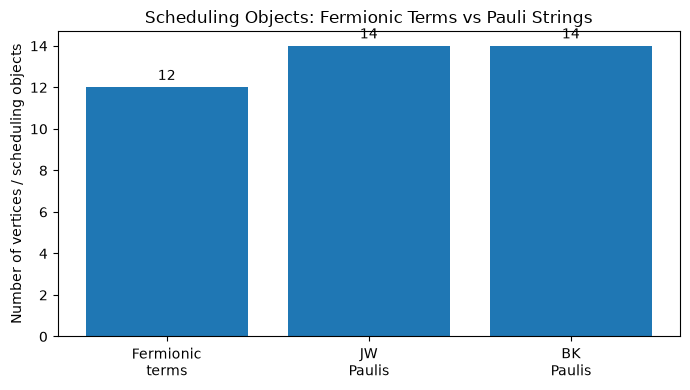

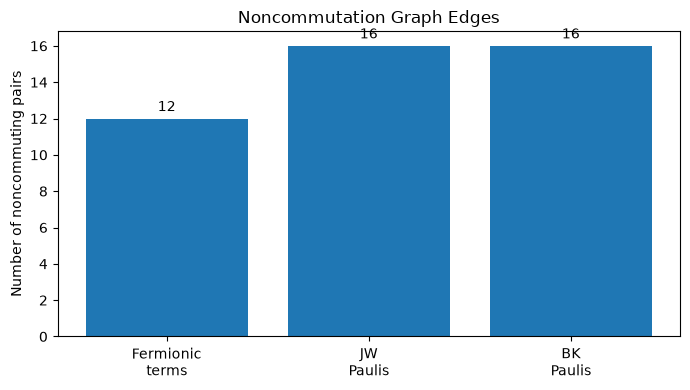

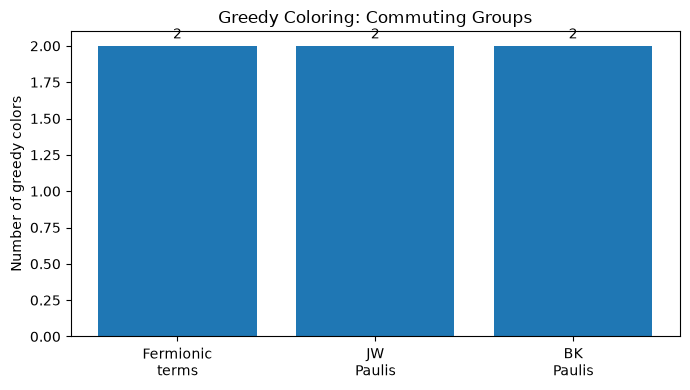

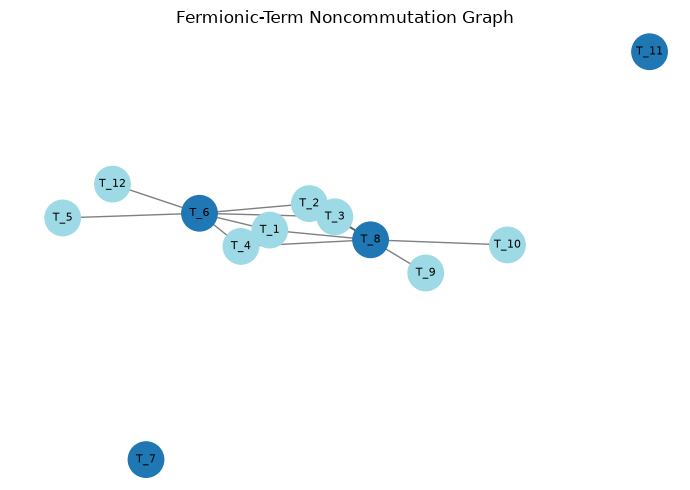

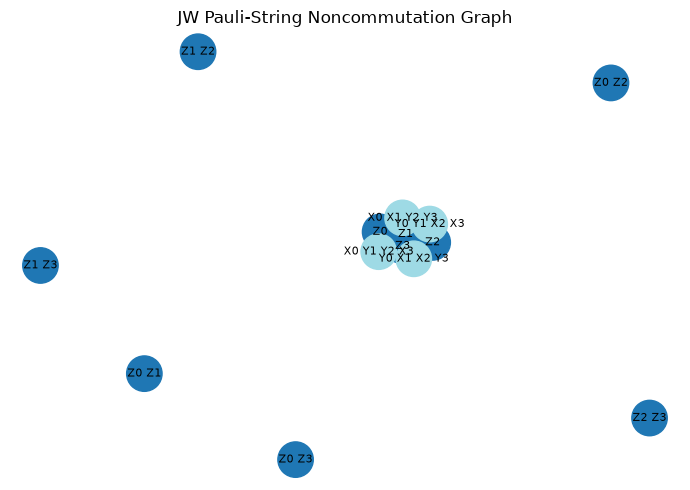

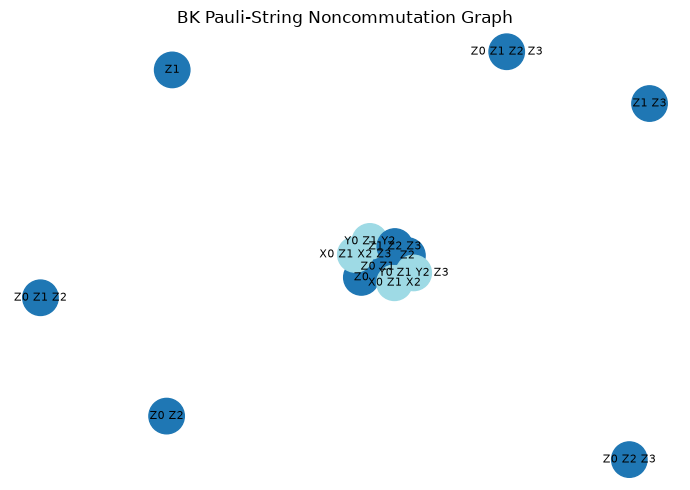

In [14]:
# New Cell 6: Fermionic-term graph vs Pauli-string graph
#
# Purpose:
#   Compare the scheduling graph built from fermionic terms T_i
#   against the scheduling graph built from individual Pauli strings
#   after JW/BK mapping.
#
# Main question:
#   Are there fewer objects to schedule at the fermionic-term level?

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from openfermion.transforms import jordan_wigner, bravyi_kitaev


# ------------------------------------------------------------
# Helper: BK fallback
# ------------------------------------------------------------

def apply_bk_safe(op, n_qubits):
    try:
        return bravyi_kitaev(op, n_qubits=n_qubits)
    except TypeError:
        return bravyi_kitaev(op, n_qubits)


# ------------------------------------------------------------
# Helper: format Pauli strings
# ------------------------------------------------------------

def format_pauli_key(pauli_key):
    if pauli_key == ():
        return "I"
    return " ".join([f"{pauli}{qubit}" for qubit, pauli in pauli_key])


def pauli_support_from_qubit_operator(qubit_op, include_identity=False, tol=1e-12):
    """
    Return nonzero Pauli strings in a QubitOperator.
    """
    qubit_op.compress(abs_tol=tol)

    support = []

    for pauli_key, coeff in qubit_op.terms.items():
        if abs(coeff) <= tol:
            continue

        if (not include_identity) and pauli_key == ():
            continue

        support.append((pauli_key, coeff))

    support = sorted(support, key=lambda x: (len(x[0]), x[0]))

    return support


# ------------------------------------------------------------
# Pauli commutation rule
# ------------------------------------------------------------

def pauli_strings_commute(pauli_a, pauli_b):
    """
    Two Pauli strings commute iff the number of sites where
    they have different non-identity Paulis is even.
    """
    dict_a = dict(pauli_a)
    dict_b = dict(pauli_b)

    anticommute_count = 0

    for qubit in set(dict_a) & set(dict_b):
        if dict_a[qubit] != dict_b[qubit]:
            anticommute_count += 1

    return (anticommute_count % 2) == 0


# ------------------------------------------------------------
# Build Pauli-string noncommutation graph
# ------------------------------------------------------------

def build_pauli_noncommutation_graph(qubit_op, graph_name, include_identity=False):
    """
    Vertex = one Pauli string in the full mapped Hamiltonian.
    Edge = pair of Pauli strings that do not commute.
    """
    support = pauli_support_from_qubit_operator(
        qubit_op,
        include_identity=include_identity,
    )

    P_graph = nx.Graph()

    for idx, (pauli_key, coeff) in enumerate(support):
        P_graph.add_node(
            idx,
            label=f"P_{idx}",
            pauli_key=pauli_key,
            pauli_string=format_pauli_key(pauli_key),
            coefficient=coeff,
        )

    for i, j in combinations(P_graph.nodes(), 2):
        pauli_i = P_graph.nodes[i]["pauli_key"]
        pauli_j = P_graph.nodes[j]["pauli_key"]

        if not pauli_strings_commute(pauli_i, pauli_j):
            P_graph.add_edge(i, j)

    coloring = nx.coloring.greedy_color(P_graph, strategy="largest_first")

    nx.set_node_attributes(P_graph, coloring, "color")

    return P_graph, coloring


# ------------------------------------------------------------
# Build scheduled fermionic graph
# ------------------------------------------------------------
# Remove the identity term because it only contributes a global phase
# and is not a meaningful Trotter scheduling object.

def is_identity_fermion_operator(op, tol=1e-12):
    op = normal_ordered(op)
    op.compress(abs_tol=tol)

    if len(op.terms) != 1:
        return False

    only_key = next(iter(op.terms.keys()))
    return only_key == ()


fermionic_scheduled_nodes = [
    node for node in G.nodes()
    if not is_identity_fermion_operator(G.nodes[node]["operator"])
]

G_fermion_sched = G.subgraph(fermionic_scheduled_nodes).copy()

fermion_coloring_sched = nx.coloring.greedy_color(
    G_fermion_sched,
    strategy="largest_first",
)

nx.set_node_attributes(G_fermion_sched, fermion_coloring_sched, "color")


# ------------------------------------------------------------
# Build full JW and BK Pauli Hamiltonians
# ------------------------------------------------------------

JW_full = jordan_wigner(Hf)
JW_full.compress(abs_tol=1e-12)

BK_full = apply_bk_safe(Hf, n_qubits=n_qubits)
BK_full.compress(abs_tol=1e-12)


# ------------------------------------------------------------
# Build Pauli-string graphs
# ------------------------------------------------------------

G_JW_pauli, JW_pauli_coloring = build_pauli_noncommutation_graph(
    JW_full,
    graph_name="JW Pauli graph",
    include_identity=False,
)

G_BK_pauli, BK_pauli_coloring = build_pauli_noncommutation_graph(
    BK_full,
    graph_name="BK Pauli graph",
    include_identity=False,
)


# ------------------------------------------------------------
# Count Pauli appearances from mapping each fermionic term individually
# ------------------------------------------------------------

def pauli_appearance_stats_from_fermionic_terms(mapping="JW", include_identity=False):
    """
    Count how many Pauli strings appear when each fermionic term T_i
    is mapped separately.

    This is useful because one fermionic term can map to many Pauli strings.
    """
    mapping = mapping.upper()

    total_appearances = 0
    union_support = set()

    for node in sorted(G.nodes()):
        T_i = G.nodes[node]["operator"]

        if mapping == "JW":
            Q_i = jordan_wigner(T_i)
        elif mapping == "BK":
            Q_i = apply_bk_safe(T_i, n_qubits=n_qubits)
        else:
            raise ValueError("mapping must be JW or BK.")

        Q_i.compress(abs_tol=1e-12)

        for pauli_key, coeff in Q_i.terms.items():
            if abs(coeff) <= 1e-12:
                continue

            if (not include_identity) and pauli_key == ():
                continue

            total_appearances += 1
            union_support.add(pauli_key)

    if mapping == "JW":
        Q_full = JW_full
    else:
        Q_full = BK_full

    full_support = {
        pauli_key
        for pauli_key, coeff in Q_full.terms.items()
        if abs(coeff) > 1e-12 and (include_identity or pauli_key != ())
    }

    duplication_ratio = total_appearances / len(full_support)

    return {
        "mapping": mapping,
        "sum_Pauli_appearances_from_individual_Ti": total_appearances,
        "unique_Paulis_before_cancellation": len(union_support),
        "unique_Paulis_in_full_H": len(full_support),
        "duplication_ratio": duplication_ratio,
    }


jw_appearance_stats = pauli_appearance_stats_from_fermionic_terms("JW")
bk_appearance_stats = pauli_appearance_stats_from_fermionic_terms("BK")


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

graph_summary_df = pd.DataFrame(
    [
        {
            "graph_type": "Fermionic-term graph",
            "mapping": "None",
            "vertices_to_schedule": G_fermion_sched.number_of_nodes(),
            "noncommuting_pairs": G_fermion_sched.number_of_edges(),
            "colors": len(set(fermion_coloring_sched.values())),
        },
        {
            "graph_type": "Pauli-string graph",
            "mapping": "JW",
            "vertices_to_schedule": G_JW_pauli.number_of_nodes(),
            "noncommuting_pairs": G_JW_pauli.number_of_edges(),
            "colors": len(set(JW_pauli_coloring.values())),
        },
        {
            "graph_type": "Pauli-string graph",
            "mapping": "BK",
            "vertices_to_schedule": G_BK_pauli.number_of_nodes(),
            "noncommuting_pairs": G_BK_pauli.number_of_edges(),
            "colors": len(set(BK_pauli_coloring.values())),
        },
    ]
)

appearance_summary_df = pd.DataFrame(
    [
        jw_appearance_stats,
        bk_appearance_stats,
    ]
)

print("=== Fermionic-term graph vs Pauli-string graph ===")
display(graph_summary_df)

print("\n=== Pauli-string appearances when mapping fermionic terms individually ===")
display(appearance_summary_df)


# ------------------------------------------------------------
# Bar plots
# ------------------------------------------------------------

plot_labels = [
    "Fermionic\nterms",
    "JW\nPaulis",
    "BK\nPaulis",
]

# Vertices / objects to schedule
plt.figure(figsize=(7, 4))
bars = plt.bar(plot_labels, graph_summary_df["vertices_to_schedule"])
plt.bar_label(bars, padding=3)
plt.ylabel("Number of vertices / scheduling objects")
plt.title("Scheduling Objects: Fermionic Terms vs Pauli Strings")
plt.tight_layout()
plt.show()


# Noncommuting pairs
plt.figure(figsize=(7, 4))
bars = plt.bar(plot_labels, graph_summary_df["noncommuting_pairs"])
plt.bar_label(bars, padding=3)
plt.ylabel("Number of noncommuting pairs")
plt.title("Noncommutation Graph Edges")
plt.tight_layout()
plt.show()


# Colors
plt.figure(figsize=(7, 4))
bars = plt.bar(plot_labels, graph_summary_df["colors"])
plt.bar_label(bars, padding=3)
plt.ylabel("Number of greedy colors")
plt.title("Greedy Coloring: Commuting Groups")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Draw the graphs for H2
# ------------------------------------------------------------

def draw_graph_with_labels(graph, title, label_attribute):
    plt.figure(figsize=(7, 5))

    pos = nx.spring_layout(graph, seed=7)

    node_colors = [
        graph.nodes[node].get("color", 0)
        for node in graph.nodes()
    ]

    labels = {
        node: graph.nodes[node].get(label_attribute, str(node))
        for node in graph.nodes()
    }

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color=node_colors,
        cmap=plt.cm.tab20,
        node_size=650,
    )

    nx.draw_networkx_edges(
        graph,
        pos,
        alpha=0.5,
    )

    nx.draw_networkx_labels(
        graph,
        pos,
        labels=labels,
        font_size=8,
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


draw_graph_with_labels(
    G_fermion_sched,
    "Fermionic-Term Noncommutation Graph",
    label_attribute="label",
)

draw_graph_with_labels(
    G_JW_pauli,
    "JW Pauli-String Noncommutation Graph",
    label_attribute="pauli_string",
)

draw_graph_with_labels(
    G_BK_pauli,
    "BK Pauli-String Noncommutation Graph",
    label_attribute="pauli_string",
)


=== JW Pauli-string noncommutation graph ===
Number of vertices: 14
Number of edges: 16

Noncommuting edges:
Z0  --  X0 X1 Y2 Y3
Z0  --  X0 Y1 Y2 X3
Z0  --  Y0 X1 X2 Y3
Z0  --  Y0 Y1 X2 X3
Z1  --  X0 X1 Y2 Y3
Z1  --  X0 Y1 Y2 X3
Z1  --  Y0 X1 X2 Y3
Z1  --  Y0 Y1 X2 X3
Z2  --  X0 X1 Y2 Y3
Z2  --  X0 Y1 Y2 X3
Z2  --  Y0 X1 X2 Y3
Z2  --  Y0 Y1 X2 X3
Z3  --  X0 X1 Y2 Y3
Z3  --  X0 Y1 Y2 X3
Z3  --  Y0 X1 X2 Y3
Z3  --  Y0 Y1 X2 X3

=== BK Pauli-string noncommutation graph ===
Number of vertices: 14
Number of edges: 16

Noncommuting edges:
Z0  --  X0 Z1 X2
Z0  --  Y0 Z1 Y2
Z0  --  X0 Z1 X2 Z3
Z0  --  Y0 Z1 Y2 Z3
Z2  --  X0 Z1 X2
Z2  --  Y0 Z1 Y2
Z2  --  X0 Z1 X2 Z3
Z2  --  Y0 Z1 Y2 Z3
Z0 Z1  --  X0 Z1 X2
Z0 Z1  --  Y0 Z1 Y2
Z0 Z1  --  X0 Z1 X2 Z3
Z0 Z1  --  Y0 Z1 Y2 Z3
X0 Z1 X2  --  Z1 Z2 Z3
Y0 Z1 Y2  --  Z1 Z2 Z3
Z1 Z2 Z3  --  X0 Z1 X2 Z3
Z1 Z2 Z3  --  Y0 Z1 Y2 Z3


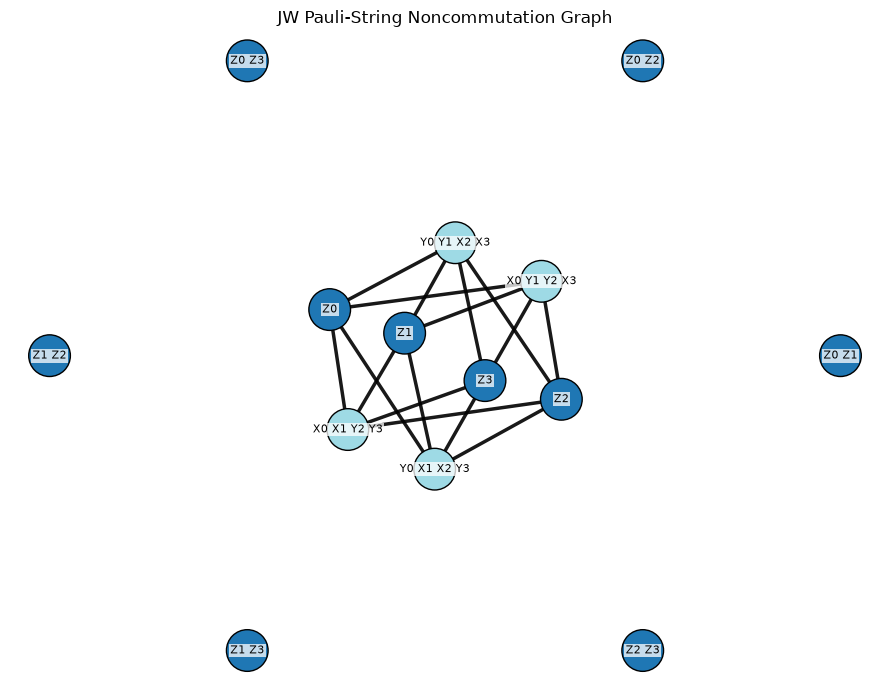

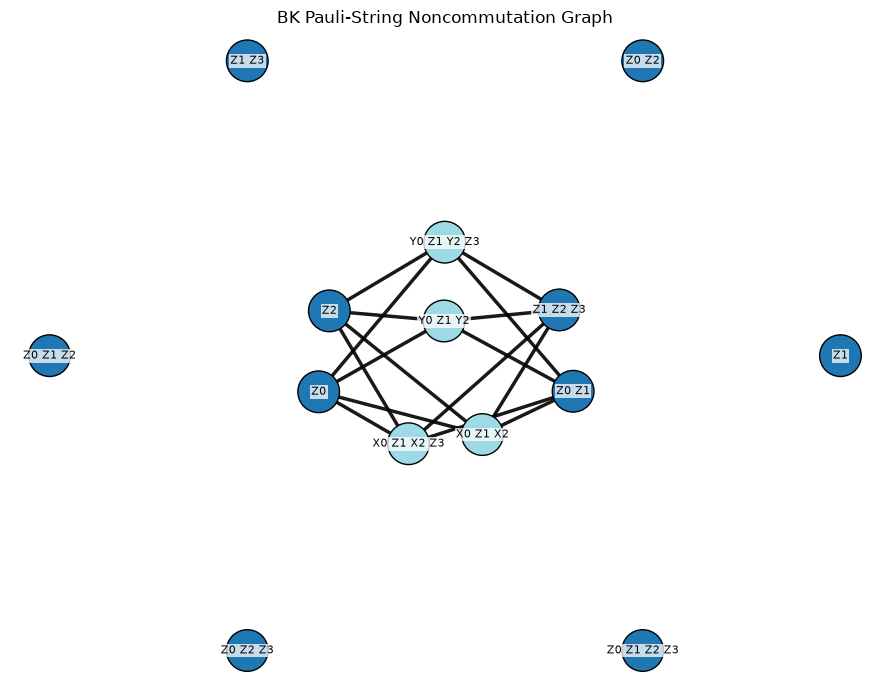

In [15]:
# New Cell 7: Better Pauli graph visualization with visible edges

def print_graph_edges(graph, title):
    print(f"\n=== {title} ===")
    print("Number of vertices:", graph.number_of_nodes())
    print("Number of edges:", graph.number_of_edges())

    if graph.number_of_edges() == 0:
        print("No noncommuting edges.")
        return

    print("\nNoncommuting edges:")
    for u, v in graph.edges():
        label_u = graph.nodes[u].get("pauli_string", graph.nodes[u].get("label", str(u)))
        label_v = graph.nodes[v].get("pauli_string", graph.nodes[v].get("label", str(v)))
        print(f"{label_u}  --  {label_v}")


def draw_graph_visible_edges(graph, title, label_attribute):
    """
    Draw graph with edges made very visible.

    Isolated vertices are placed in an outer shell.
    Non-isolated vertices are placed in the center.
    """
    plt.figure(figsize=(9, 7))

    isolated_nodes = list(nx.isolates(graph))
    connected_nodes = [node for node in graph.nodes() if node not in isolated_nodes]

    # Build positions manually:
    # connected component near center, isolated nodes around outside.
    pos = {}

    if connected_nodes:
        connected_subgraph = graph.subgraph(connected_nodes)
        pos_connected = nx.spring_layout(
            connected_subgraph,
            seed=7,
            k=1.2,
            iterations=100,
        )
        pos.update(pos_connected)

    if isolated_nodes:
        angle_values = np.linspace(0, 2 * np.pi, len(isolated_nodes), endpoint=False)
        radius = 3.0

        for node, theta in zip(isolated_nodes, angle_values):
            pos[node] = np.array([radius * np.cos(theta), radius * np.sin(theta)])

    node_colors = [
        graph.nodes[node].get("color", 0)
        for node in graph.nodes()
    ]

    labels = {
        node: graph.nodes[node].get(label_attribute, str(node))
        for node in graph.nodes()
    }

    # Draw edges first and make them thick/dark
    nx.draw_networkx_edges(
        graph,
        pos,
        edge_color="black",
        width=2.5,
        alpha=0.9,
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color=node_colors,
        cmap=plt.cm.tab20,
        node_size=900,
        edgecolors="black",
        linewidths=1.0,
    )

    # Draw labels with white background so they are readable
    nx.draw_networkx_labels(
        graph,
        pos,
        labels=labels,
        font_size=8,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.0,
        ),
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Print edge lists first
# ------------------------------------------------------------

print_graph_edges(
    G_JW_pauli,
    "JW Pauli-string noncommutation graph",
)

print_graph_edges(
    G_BK_pauli,
    "BK Pauli-string noncommutation graph",
)


# ------------------------------------------------------------
# Redraw graphs with visible edges
# ------------------------------------------------------------

draw_graph_visible_edges(
    G_JW_pauli,
    "JW Pauli-String Noncommutation Graph",
    label_attribute="pauli_string",
)

draw_graph_visible_edges(
    G_BK_pauli,
    "BK Pauli-String Noncommutation Graph",
    label_attribute="pauli_string",
)